Master: SNA/CNA Lab - Complex Network Analysis
====================================

Chiara Boldrini, 2026
----------------

# Analysis of Complex Networks with python and  networkx
The lab is divided in four parts

1. creating and manipulating graphs
2. visualising graphs
3. analysing graphs
4. generating representative graphs

We use a dataset of real Facebook interaction graph

  - a weighted graph, weights represent the frequency of interaction
  - a directed graph

In some cases, we use a small (directed) toy graph

# Part 0. Import useful stuff

In [14]:
# interactive plots in Jupyter, used to show plots inline in the notebook (compatibility, enabled by default in modern notebook setup)
# %matplotlib inline

# The networkx library
import networkx as nx

# Numpy for enhanced math array management
import numpy as np

# statistical tools (we only use ECDF)
from statsmodels.distributions.empirical_distribution import ECDF

# Mathematical plotting
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# use to control whether to show the entire cell output or only the last_expr (default)
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# to generate random numbers
from random import *

# to fit power law distributions
import powerlaw

__Notes__

  - $\tt{networkx}$ imports the bulk of what we use
  - we use $\tt{numpy}$ for advanced handling of data in arrays, and because mathematical plotting typically assumes that data are Numpy arrays
  - $\tt{matplotlib}$ is an extended set of graphical math packages
    - we use $\tt{pyplot}$ for plotting
  - $\tt{statsmodel}$ provides several statistical tools
    - we use a specific function $\tt{ECDF()}$ to generate CCDF plots
    
Packages needed are

  - Networkx https://networkx.org/
  - Numpy http://www.numpy.org/
  - Matplotlib https://matplotlib.org/
  - Statsmodel http://www.statsmodels.org/stable/index.html
  - Jupyter (if you want to try the notebook functions) http://jupyter.org/
  - Cairo and PyCairo (sometimes the package name can be py3cairo, with a corresponding py2cairo for Python2 APIs)
 
Install them either via conda or via pip3, e.g.
  - networkx: pip3 install networkx
  - powerlaw: pip3 install powerlaw
  - cairo: pip3 install cairo (or conda install cairo)
  - pycairo: pip3 install pycairo (or conda install pycairo)

# Part 1. Reading graphs from files / writing graphs to files + graph basics

The following basic graph types are provided as Python classes:

**Graph**: 
This class implements an undirected graph. It ignores multiple edges between two nodes. It does allow self-loop edges between a node and itself.

**DiGraph**:
Directed graphs, that is, graphs with directed edges. Provides operations common to directed graphs, (a subclass of Graph).



In [15]:
# By default, a graph is read as undirected

fg = nx.read_edgelist(
    "./Amazon0601.txt",
    comments="#",
    delimiter="\t",
    nodetype=int,
    create_using=nx.DiGraph()
)
print(type(fg))
print(fg)

<class 'networkx.classes.digraph.DiGraph'>
DiGraph with 112177 nodes and 507543 edges


__Notes__

  - $\texttt{ncol}$ is a simple format of the kind $\texttt{n1 n2 <weight>}$
    - the third column is optional, and by default it is considered as the weight of the link, if present
  - the `read_weighted_edgelist` reads edges as column 1 -> colum2 weight (the ordering is important for directed graphs)

### Writing graphs to files
with the $\tt{write\_<filetype>()}$ method

In [16]:
nx.write_pajek(fg, "./Amazon0601.pajek")

## Graph basics

In [17]:
print(fg)

DiGraph with 112177 nodes and 507543 edges


__The undirected version of the graph__

In [18]:
fg_u = fg.to_undirected()

print(fg_u)

fg_u.number_of_nodes()
len(fg_u) # equivalent to .number_of_nodes()

fg_u.number_of_edges()
fg.number_of_edges() # the number of edges is different in the directed version

# you can also do this
nx.number_of_nodes(fg_u)
nx.number_of_edges(fg_u)

Graph with 112177 nodes and 382711 edges


112177

112177

382711

507543

112177

382711

If you want to access the nodes, you can use `fg_u.nodes` (property of class Graph) or `fg_u.nodes()` (function that wraps the property). This returns a NodeView object. It may look like a Python list but it is not (it's a more efficient way of handling access to nodes). A NodeView is a special object that provides a dynamic view of the nodes in a graph.

In [13]:
print(type(fg_u))
print(type(fg_u.nodes))

# list nodes (all equivalent)
list(fg_u)[0:10]
list(fg_u.nodes)[0:10] # NodeView converted to list
list(fg_u.nodes())[0:10] # # NodeView converted to list (== identical to nodes ==)

# list nodes with attributes (all equivalent)
list(fg_u.nodes.data())[0:10] # # NodeView converted to list (== identical to nodes ==)
list(fg_u.nodes(data=True))[0:10] # NodeView converted to list, with data=True you get the attributes of nodes

# get neighbors of node (neighbors = nodes directly reachable from node "2") // for directed graphs, it considers the out-edges
list(fg_u.neighbors(2))[0:10] # 


<class 'networkx.classes.graph.Graph'>
<class 'networkx.classes.reportviews.NodeView'>


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

[(0, {}),
 (1, {}),
 (2, {}),
 (3, {}),
 (4, {}),
 (5, {}),
 (6, {}),
 (7, {}),
 (8, {}),
 (9, {})]

[(0, {}),
 (1, {}),
 (2, {}),
 (3, {}),
 (4, {}),
 (5, {}),
 (6, {}),
 (7, {}),
 (8, {}),
 (9, {})]

[0, 1, 3, 4, 6, 10, 47, 54, 118, 355]

Same for edges. NodeView => EdgeView

In [ ]:
# list edges
list(fg_u.edges)[0:5] # EdgeView converted to list of tuples (tuple: ordered, allows duplicates, immutable)
list(fg_u.edges())[0:5] # EdgeView (== identical to edges ==)

# list edges with attributes (e.g., weights) => weights are read as floats by default
list(fg_u.edges.data())[0:5]
list(fg_u.edges(data=True))[0:5] # data=True => all attributes are returned

# get edges 
list(fg_u.edges([8, 7])) # only edges *from* these nodes

[(0, 1), (0, 2), (0, 3), (0, 4), (0, 5)]

[(0, 1), (0, 2), (0, 3), (0, 4), (0, 5)]

[(0, 1, {}), (0, 2, {}), (0, 3, {}), (0, 4, {}), (0, 5, {})]

[(0, 1, {}), (0, 2, {}), (0, 3, {}), (0, 4, {}), (0, 5, {})]

[(8, 0),
 (8, 4),
 (8, 5),
 (8, 36),
 (8, 44),
 (8, 51),
 (8, 59),
 (8, 60),
 (8, 61),
 (8, 62),
 (8, 63),
 (8, 233),
 (8, 1056),
 (8, 1057),
 (8, 1058),
 (8, 1059),
 (8, 1060),
 (8, 1061),
 (8, 1529),
 (8, 2494),
 (8, 1575),
 (8, 2197),
 (8, 2752),
 (8, 2754),
 (8, 2198),
 (8, 5164),
 (8, 10309),
 (8, 7446),
 (8, 12606),
 (8, 11554),
 (8, 6984),
 (8, 5543),
 (8, 18453),
 (8, 31205),
 (7, 0),
 (7, 5),
 (7, 6),
 (7, 9),
 (7, 46),
 (7, 47),
 (7, 54),
 (7, 58),
 (7, 108),
 (7, 1521),
 (7, 1522),
 (7, 9997)]

**Note**: for directed graphs `edges` returns the out-edges!

In [4]:
# if graph directed, be careful
list(fg.edges("8"))
list(fg.out_edges("8")) # out-edges
list(fg.in_edges("8")) # in-edges

# check if edge exists
fg.has_edge("7", "8")
fg.has_edge("8", "7")

fg_u.has_edge("7", "8")
fg_u.has_edge("8", "7")

[]

[]

[]

False

False

NameError: name 'fg_u' is not defined

**Clarification**

*Reading a directed graph as undirected in networkx.*

The edges that appears last is retained! 

From: 
` ('a', 'b', {'weight': 0.02}),
 ('b', 'a', {'weight': 0.01})`

 to

 `('b', 'a', {'weight': 0.01})`

In [18]:
# By default, a graph is read as undirected
toy_g = nx.read_weighted_edgelist("./toy_graph_2.ncol")
print(toy_g)

list(toy_g.edges(data=True))

# we need to state it explictly if we want to import the graph as directed
toy_g = nx.read_weighted_edgelist("./toy_graph_2.ncol", create_using=nx.DiGraph)
print(toy_g)

list(toy_g.edges(data=True)) 

FileNotFoundError: [Errno 2] No such file or directory: './toy_graph_2.ncol'

# Part 2. Connected components, Giant Component & Subgraphs

In [ ]:
toy_g = nx.read_weighted_edgelist("./toy_graph_2.ncol", create_using=nx.DiGraph)
print(toy_g)

list(toy_g.nodes)
list(toy_g.edges)

DiGraph with 7 nodes and 9 edges


['1', '2', '3', '4', '5', 'a', 'b']

[('1', '2'),
 ('1', '3'),
 ('1', '4'),
 ('1', '5'),
 ('2', '5'),
 ('3', '4'),
 ('5', 'a'),
 ('a', 'b'),
 ('b', 'a')]

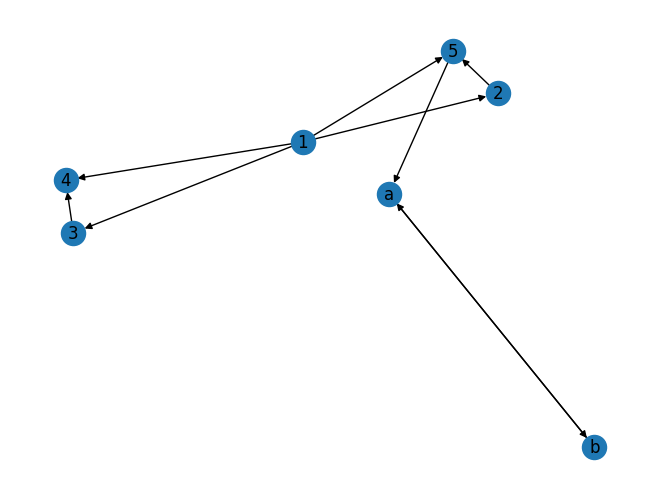

In [ ]:
nx.draw(toy_g, with_labels=True, pos = nx.spring_layout(toy_g, seed=42))

In [ ]:
# Check whether the graph is connected or not
nx.is_strongly_connected(toy_g)
nx.is_weakly_connected(toy_g)


False

True

In [ ]:

# Delete edge and try again
toy_g.remove_edge("5","a")
nx.is_weakly_connected(toy_g)

False

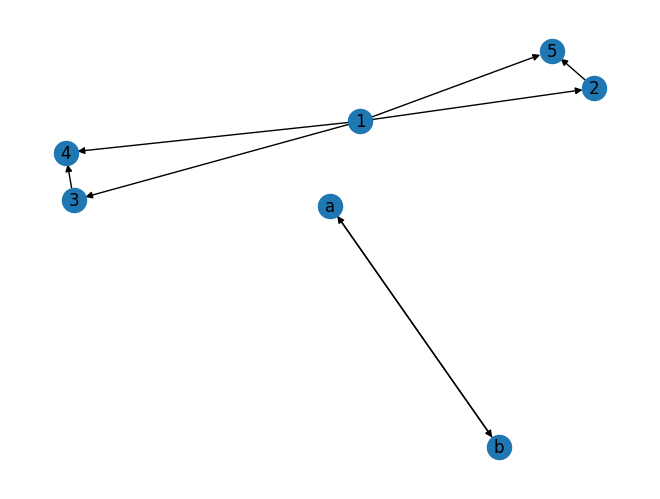

In [ ]:
nx.draw(toy_g, with_labels=True, pos = nx.spring_layout(toy_g, seed=42))

In [ ]:
# Number of connected components
nx.number_weakly_connected_components(toy_g)

# Compute the connected components in the graph
#   - "WEAK" does not consider the direction of edges
# `weakly_connected_components` return a generator (a "sort" of more efficient list, so we convert to list for simplicity of use, the inner elements are converted to python sets)
# set — unordered (so no indexing), no duplicates, mutable
toy_g_conn_comp = list(nx.weakly_connected_components(toy_g)) 

print(toy_g_conn_comp) # it's a list of sets => {...}

# the number of components
len(toy_g_conn_comp)

# the sizes of the components
[len(cc) for cc in sorted(toy_g_conn_comp, key=len, reverse=True)] # reverse = True => decreasing // key=len sorts the sets in the list according to their length

# the set of vertices in the first component
toy_g_conn_comp[0]

# membership: to which component node i belongs to
membership = [i for i in range(len(toy_g_conn_comp)) for n in toy_g.nodes() if n in toy_g_conn_comp[i] ]
membership

# the Giant Component (the biggest components)
max(nx.weakly_connected_components(toy_g), key=len)
toy_g_GC = toy_g.subgraph(max(nx.weakly_connected_components(toy_g), key=len))
print(toy_g_GC)

2

[{'1', '4', '5', '2', '3'}, {'b', 'a'}]


2

[5, 2]

{'1', '2', '3', '4', '5'}

[0, 0, 0, 0, 0, 1, 1]

{'1', '2', '3', '4', '5'}

DiGraph with 5 nodes and 6 edges


### The Giant Component of the Facebook dataset

In [ ]:
# weakly connected components means that it is sufficient that nodes are connected via a unidirected path
# strongly connected components means that nodes must be mutually connected via two unidirected paths
fg_cc = list(nx.weakly_connected_components(fg))

# we extract the GC from the Facebook graph
fb_GC = nx.subgraph(fg, max(fg_cc, key=len))

print(f'The original Facebook graph has {fg.number_of_nodes()} nodes and {fg.number_of_edges()} edges')
print(f'The GC in the Facebook graph has {fb_GC.number_of_nodes()} nodes and {fb_GC.number_of_edges()} edges')

# number of connected components
len(fg_cc)
nx.number_weakly_connected_components(fg) # same as above

# sizes (sorted, first 20 elements)
[len(c) for c in sorted(fg_cc, key=len, reverse=True)][0:19]



The original Facebook graph has 45813 nodes and 264004 edges
The GC in the Facebook graph has 43953 nodes and 262631 edges


842

842

[43953, 6, 5, 5, 5, 5, 5, 5, 5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]

__Note__: be careful when working with generators (`max` "destroys" the generator)

In [ ]:
def numbers():
    for i in range(5):
        yield i

nums = numbers()  # Create a generator
print(max(nums))   # Output: 4
print(list(nums))  # Output: [] 

# compare the above with:
nums = list(numbers())  # Create a generator but convert it to list immediately
print(max(nums))   # Output: 4
print(list(nums))  # Output: [0, 1, 2, 3, 4]


4
[]
4
[0, 1, 2, 3, 4]


### Induced subgraph

In [ ]:
# Select only nodes with degree > 100 from the FB Giant Component
vs = [n for n in list(fb_GC.nodes) if fb_GC.degree(n) > 100]

# "Induced" subgraph: graph composed by
# - a set of vertices (from the original graph)
# - only the edges connecting those vertices (in the original subgraph)
fb_g_sub = fb_GC.subgraph(vs)

nx.number_weakly_connected_components(fb_g_sub)

[len(cc) for cc in nx.weakly_connected_components(fb_g_sub)]

10

[225, 1, 4, 1, 1, 1, 1, 1, 1, 1]

__Notes__

- what you see is not a connected component of the __original__ Facebook graph
    - the subgraph has taken all vertices in the GC, whose degree is higher than 100, and the link __between__ these nodes
    - therefore, the selected vertices usually have many more edges in the GC (towards vertices with degree <= 100) which one does not see in the plot

# Part 3. Plotting graphs

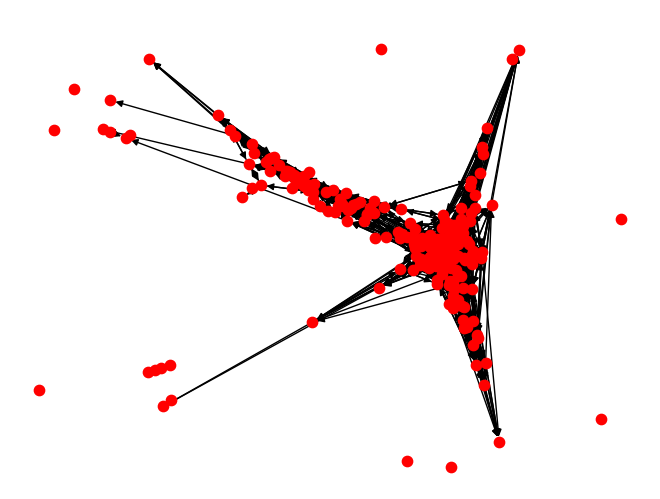

In [ ]:
# Example with the Facebook induced graph with nodes having degree > 100

# Beautyfying the the plot with some visual style attributes
# - define a dictionary for setting the required options
# - use the dictionary as the plot parameter

visual_style = {}
    

visual_style["with_labels"] = False
visual_style["node_size"] = 55 #default 300
visual_style["node_color"] = 'red'
visual_style["node_shape"] = 'o' # Marker symbols: s=square, o=circle, ^=triangle up, >=triangle right, v=triangle down, <=triangle left, d=thin diamond, p=pentagon, h=hexagon, 8=octagon
visual_style["arrowsize"] = 10 # 10 default
visual_style["pos"] = nx.spring_layout(fb_g_sub, seed = 25) # the spring layout is the default one used by draw
# visual_style["pos"] = nx.random_layout(fb_g_sub, seed = 25) # vs random

# spring_layout() uses Fruchterman-Reingold force-directed algorithm: it simulates a force-directed representation of the network treating edges as springs holding nodes close,
# while treating nodes as repelling objects, sometimes called an anti-gravity force.

nx.draw(fb_g_sub, **visual_style) # The ** operator unpacks a dictionary into named arguments

<Figure size 1000x600 with 0 Axes>

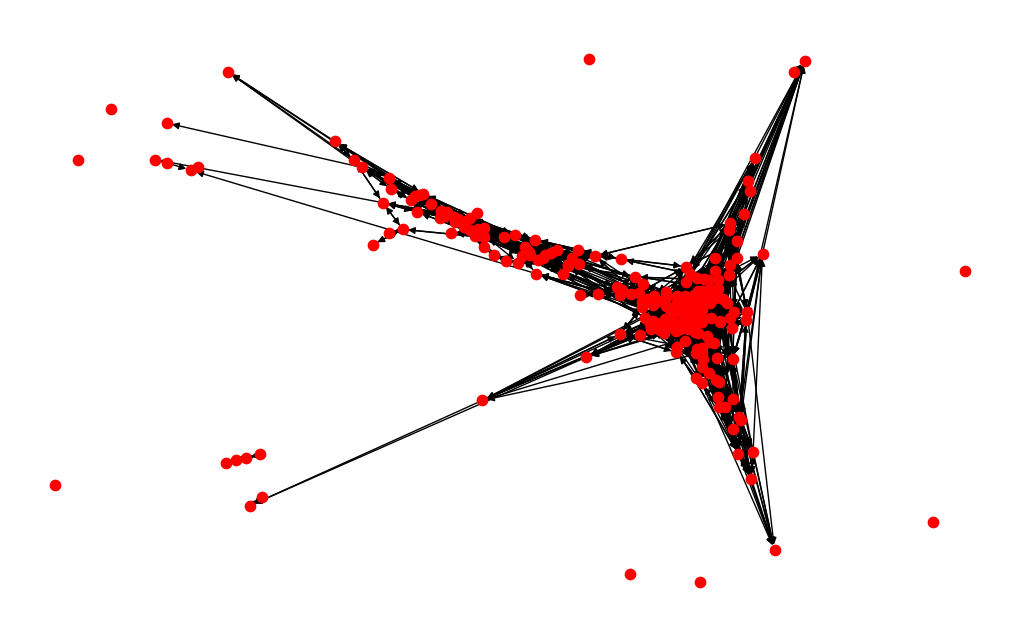

In [ ]:
# we make it larger
plt.figure(figsize=(10, 6))  # width, height in inches
nx.draw(fb_g_sub, **visual_style)

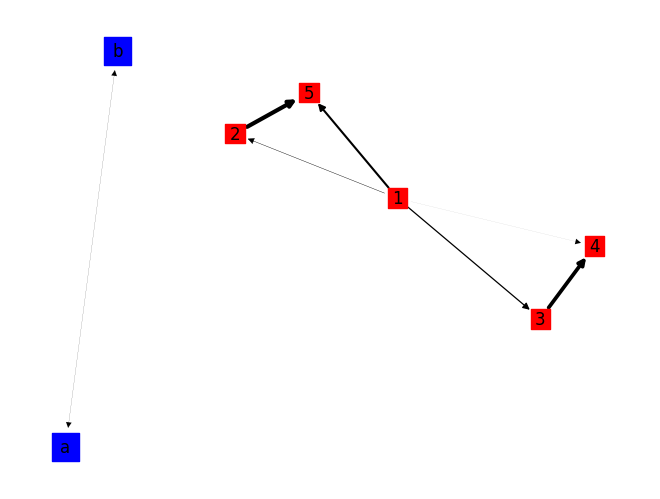

In [ ]:
# Plotting the toy graph

colors = ['red', 'blue']
sizes = [200,400]

visual_style.clear() # empty the dict, then we start over

visual_style["with_labels"] = True
visual_style["node_size"] = [sizes[membership[i]] for i in range(toy_g.number_of_nodes())] # we use the membership variable created before
visual_style["node_color"] = [colors[membership[i]] for i in range(toy_g.number_of_nodes())]
visual_style["width"] = np.array([e[2] for e in list(toy_g.edges(data="weight"))])*3 # we make the edge width proportional to the edge weight (you *need* np, if you do list()*3, it replicates the list 3 times! see example below)
visual_style["node_shape"] = "s" # nx.draw doesn't accept lists of shape marked [it's a matplotlib limitation] (you would need to draw nodes in groups)
visual_style["pos"] = nx.spring_layout(toy_g, seed = 25)

nx.draw(toy_g, **visual_style)
plt.savefig('toy_g_plot.pdf')

In [ ]:
# example of why you need 
[e[2] for e in list(toy_g.edges(data="weight"))] # original list
[e[2] for e in list(toy_g.edges(data="weight"))]*3 # list * 3
np.array([e[2] for e in list(toy_g.edges(data="weight"))])*3 # correct elementwise multiplication with numpy

[0.1, 0.3, 0.01, 0.5, 1.0, 0.9, 0.02, 0.01]

[0.1,
 0.3,
 0.01,
 0.5,
 1.0,
 0.9,
 0.02,
 0.01,
 0.1,
 0.3,
 0.01,
 0.5,
 1.0,
 0.9,
 0.02,
 0.01,
 0.1,
 0.3,
 0.01,
 0.5,
 1.0,
 0.9,
 0.02,
 0.01]

array([0.3 , 0.9 , 0.03, 1.5 , 3.  , 2.7 , 0.06, 0.03])

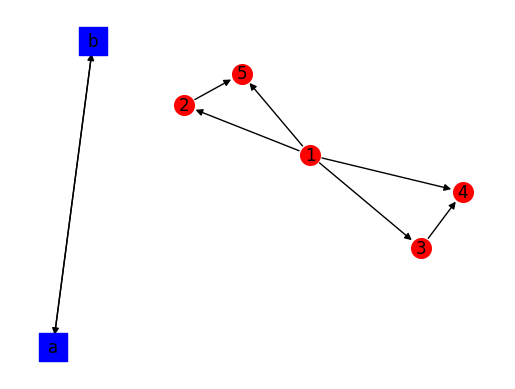

In [ ]:
# In NetworkX, if you want different shapes, you must draw nodes in groups.

pos=nx.spring_layout(toy_g, seed = 25)
shapes = ["o", "s"]
# Draw edges once
_ = nx.draw_networkx_edges(toy_g, pos) # _ = suppresses the displayed return value (assigns the return value to _, making it clear that you’re intentionally ignoring it)

# Draw nodes component by component
for comp_id in set(membership):
    nodes = [node for i, node in enumerate(toy_g.nodes()) if membership[i] == comp_id]
    _ = nx.draw_networkx_nodes(
        toy_g,
        pos,
        nodelist=nodes,
        node_shape=shapes[comp_id % len(shapes)],
        node_size=sizes[comp_id % len(sizes)],
        node_color=colors[comp_id % len(colors)]
    )
_ = nx.draw_networkx_labels(toy_g, pos)
# nx.draw_networkx_labels(toy_g, pos)
_ = plt.axis("off") # needed because nx.draw() is a high-level convenience function that does a few extra things for you while draw_networkx_edges/nodes re lower-level functions that only draw the requested graph elements

# Part 4. Degree Analysis

In [ ]:
# We're working with the directed version of the Facebook graph

# degree() method // for directed graphs gives indegree + outdegree
fb_deg = list(fb_GC.degree()) #  DegreeView (an efficient "window" onto the graph), turned to list (of tuples) for convenience
# dict(fb_GC.degree()): you can also convert to dict but for slicing list + tuples is more natural

# shows the first ten elements of the degree list
fb_deg[0:9] 

fb_GC.in_degree()
fb_GC.out_degree()


[('2', 34),
 ('3', 2),
 ('79', 15),
 ('872', 18),
 ('1043', 34),
 ('1847', 41),
 ('3306', 40),
 ('3372', 34),
 ('4605', 39)]

InDegreeView({'2': 14, '3': 1, '79': 9, '872': 7, '1043': 17, '1847': 17, '3306': 28, '3372': 14, '4605': 39, '5402': 44, '5875': 35, '8785': 25, '10609': 28, '10998': 5, '11186': 16, '12172': 10, '17766': 8, '18086': 15, '18745': 13, '30579': 3, '42558': 5, '5': 19, '27': 8, '108': 2, '129': 6, '207': 48, '660': 7, '1210': 5, '1509': 21, '1560': 19, '2972': 6, '4471': 9, '4879': 10, '5145': 12, '5922': 60, '6066': 31, '6644': 5, '7640': 1, '11201': 17, '13180': 2, '24682': 14, '27156': 13, '6': 2, '28': 34, '168': 5, '864': 8, '925': 14, '1087': 10, '1145': 35, '3214': 21, '4753': 60, '20523': 1, '7': 1, '8': 5, '26611': 1, '9': 19, '10': 14, '768': 57, '1208': 15, '1483': 57, '2255': 24, '3501': 11, '5842': 5, '8714': 1, '9350': 1, '10206': 19, '10749': 28, '11714': 14, '12584': 9, '14959': 17, '15161': 30, '21600': 6, '33509': 3, '38661': 7, '15': 20, '40': 18, '44': 15, '158': 22, '328': 24, '432': 8, '814': 60, '971': 5, '974': 69, '1029': 10, '1108': 66, '1359': 18, '1879': 33, '

OutDegreeView({'2': 20, '3': 1, '79': 6, '872': 11, '1043': 17, '1847': 24, '3306': 12, '3372': 20, '4605': 0, '5402': 46, '5875': 0, '8785': 23, '10609': 25, '10998': 0, '11186': 11, '12172': 11, '17766': 9, '18086': 13, '18745': 7, '30579': 3, '42558': 2, '5': 20, '27': 9, '108': 3, '129': 9, '207': 40, '660': 7, '1210': 4, '1509': 49, '1560': 10, '2972': 3, '4471': 0, '4879': 4, '5145': 0, '5922': 51, '6066': 34, '6644': 13, '7640': 4, '11201': 20, '13180': 2, '24682': 0, '27156': 6, '6': 9, '28': 38, '168': 8, '864': 0, '925': 5, '1087': 9, '1145': 14, '3214': 21, '4753': 46, '20523': 2, '7': 2, '8': 0, '26611': 1, '9': 19, '10': 26, '768': 40, '1208': 21, '1483': 0, '2255': 25, '3501': 13, '5842': 10, '8714': 1, '9350': 25, '10206': 21, '10749': 35, '11714': 10, '12584': 12, '14959': 13, '15161': 35, '21600': 5, '33509': 3, '38661': 7, '15': 15, '40': 24, '44': 26, '158': 13, '328': 23, '432': 6, '814': 53, '971': 9, '974': 45, '1029': 7, '1108': 36, '1359': 0, '1879': 0, '1983': 

In [ ]:
# the maximum degree, and the ID of the node with maximum degree [in the list, find the tuple (nodeid, degree) whose second element is largest]
#       lambda x: x[1] -> takes a tuple and returns its second element
#       key = ... -> key is an option that tells Python “when comparing elements, use THIS value instead of the element itself.” [used when ranking is not "obvious"]
id_max, dmax = max(fb_deg, key=lambda x: x[1])

print(f'The node with the max degree: ({id_max}, {dmax})')

# don't do this, this is wrong!
max(fb_deg) # uses lexicographical order

# list of node degrees, sorted
sorted(fb_deg, key=lambda x: x[1], reverse=True)[0:4]


The node with the max degree: (2420, 314)


('9999', 1)

[('2420', 314), ('6765', 302), ('7308', 276), ('2611', 263)]

In [ ]:
# the set of neighbours of the node with max degree
nei = list(fb_GC.neighbors(id_max)) # in a direct graph, this gets the SUCCESSORS! same as code below // from iterator to list
succ = list(fb_GC.successors(id_max)) # and same as list(fb_GC[id_max])
pred = list(fb_GC.predecessors(id_max))

# the number of such nodes
len(nei) # == fb_GC.out_degree(id_max)
len(succ) # == fb_GC.out_degree(id_max)
len(pred) # == fb_GC.in_degree(id_max)

# the main diff between neighbors/successors/predecessors and fb_GC[id_max] is that the former return an iterator, the latter an AtlasView (dict) which includes edge data when you iterate over it

115

115

199

Let's redo the same on the equivalent __undirected__ graph

In [ ]:
# take the undirected version of the Giant Component 
# combine_edges tells what to do with the weights (default, lost attribute; here: sum values)
fb_GC_u = fb_GC.to_undirected()

# degree() method
fb_deg_u = list(fb_GC_u.degree())
fb_deg_u[0:9]

# # the maximum degree, and the ID of the node with maximum degree
id_max, dmax = max(fb_deg_u, key=lambda x: x[1])

print(f'The node with the max degree: ({id_max}, {dmax})')

# list of node degrees, sorted
sorted(fb_deg_u, key=lambda x: x[1], reverse=True)[0:4]

# neigbors
nei = list(fb_GC_u.neighbors(id_max))
len(nei)

# print(len(list(fb_GC_u.successors(id_max)))) # uncomment to check that successors() and predecessors() are not defined for Graph (they are just for DiGraphs)

[('2', 23),
 ('3', 1),
 ('79', 11),
 ('872', 12),
 ('1043', 21),
 ('1847', 27),
 ('3306', 29),
 ('3372', 21),
 ('4605', 39)]

The node with the max degree: (2420, 223)


[('2420', 223), ('6765', 196), ('7308', 177), ('5706', 170)]

223

### Degree density and CCDF

One way to visualise the density of the degree is through a histogram

- discrete approximation of the density function
- bins = set of intervals for the random variable
- value in each bin = # of samples, absolute or normalised, which fall in the bin
    - i.e., the probability that the random variable takes values in the bin
    
networkx includes a method to compute (not draw directly!) the histogram of the degree distribution

- $\tt{degree\_histogram()}$

We also use Numpy/Matplotlib methods, which are more flexible

- Numpy: method $\tt{np.histogram()}$ computes the histogram of a set of values
- Matplotlib: method $\tt{plt.hist()}$ computes the histogram (via Numpy), and plots the result

[0, 6257, 5718, 3742, 3327, 2505, 2204, 1768, 1543, 1296]


[0, 1, 2, 3]

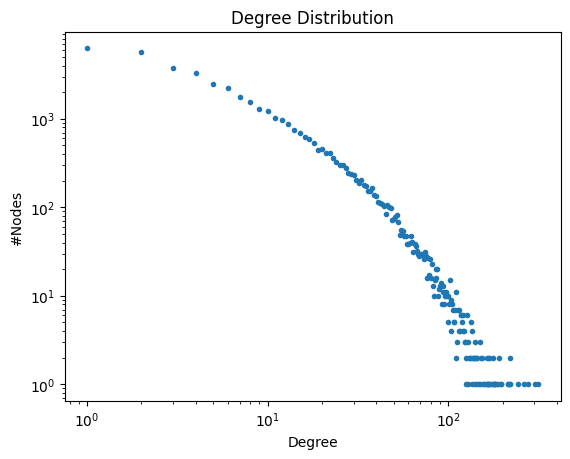

In [ ]:
hist = nx.degree_histogram(fb_GC) # return a list of frequencies of degrees. The degree values are the index in the list.

print(hist[0:10])
list(range(0, len(hist)))[0:4]

_ = plt.plot(range(0, len(hist)), hist, ".")
_ = plt.title("Degree Distribution")
_ = plt.xlabel("Degree")
_ = plt.ylabel("#Nodes")
_ = plt.loglog()

# Note that plt.loglog() automatically masks point (0,0), because log(0) is undefined (-infty)

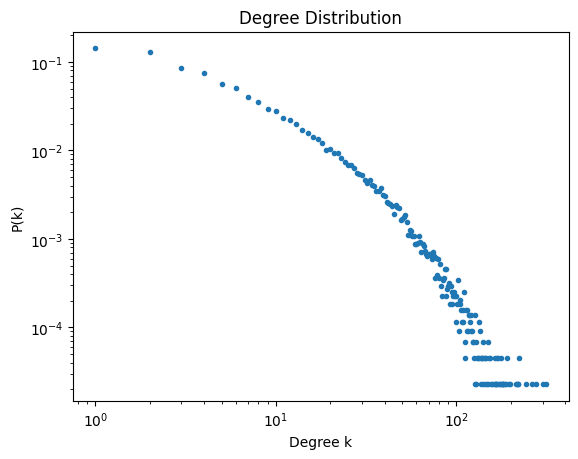

In [ ]:
# if you want to show the density instead of the raw count
pk = [c / sum(hist) for c in hist] # this is equivalent to the one below, because hist contains the number of occurrences per k (so the sum gives N)
# pk = [c / fb_GC.number_of_nodes() for c in hist] 

_ = plt.plot(range(0, len(pk)), pk, ".")
_ = plt.title("Degree Distribution")
_ = plt.xlabel("Degree k")
_ = plt.ylabel("P(k)")
_ = plt.loglog()

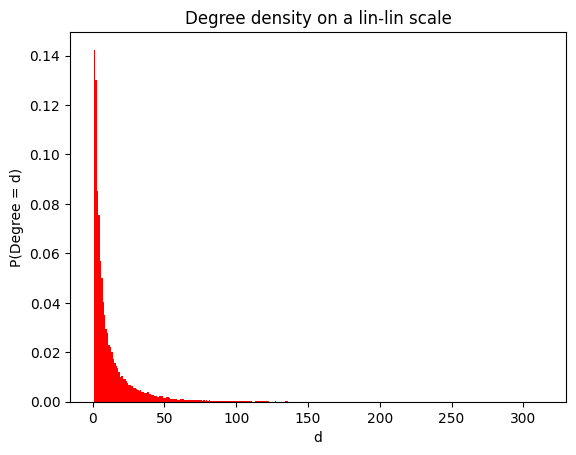

In [ ]:
# Alternative way of plotting the normalized histogram of the degree distribution
fb_deg_list = list(dict(fb_GC.degree()).values()) # degree() returns a "DiDegreeView", which we can convert to what we want. the list conversion is needed because values() returns "dict_values"

# bins=range(0,max(fb_deg_list)+1) produces integers 0, 1, 2, ..., max(fb_deg_list). The +1 is needed because range's upper bound is exclusive, so without it you'd miss the max value itself.
dd_h, dd_h_bins, _ = plt.hist(fb_deg_list, bins=range(0,max(fb_deg_list)+1), density=True, color = 'red') # the previous function was from networkx
_ = plt.xlabel("d")
_ = plt.ylabel("P(Degree = d)")
_ = plt.title("Degree density on a lin-lin scale")

# the default step of range is 1. if you want larger bins, use a step bin_width
# bin_width = 5
# bins = range(0, max(fb_deg_list) + bin_width, bin_width)

__Notes__

- Return values
    - the values of each bin ($\tt{dd\_h}$)
    - the extremes of the bins ($\tt{dd\_h\_bins}$)
        - __NB__: the number of the extremes is always the number of bins + 1!!!
    - we discard the third return value (variable $\tt{\_}$) -> patches: the rectangle objects used for plotting, usually ignored.

- Parameters
    - $\tt{fb\_deg}$ is the set of values for which the histogram is computed
    - $\tt{bins}$ is a list with the extremes of the bins
        - __NB__: $\tt{max(fb\_deg)+1}$ is because range excludes the second extreme
    - $\tt{density}$ tells whether to normalise the values of bins to 1

Plotting the histogram on log-log scale directly (`plt.xscale('log')` and `plt.yscale('log')`) will look 'wrong' because the bins will remain linear. One should compute log-spaced bins. Below we do it in another way, using the output of `plt.hist`

In [ ]:
# how do the histogram and bins look like
dd_h[0:19]
dd_h_bins[0:19]

len(dd_h)
len(dd_h_bins)

array([0.        , 0.14235661, 0.13009351, 0.0851364 , 0.07569449,
       0.0569927 , 0.05014447, 0.04022479, 0.03510568, 0.02948604,
       0.02762041, 0.02300184, 0.02200077, 0.02006689, 0.01722294,
       0.01581235, 0.01431074, 0.01362819, 0.01196733])

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16., 17., 18.])

314

315

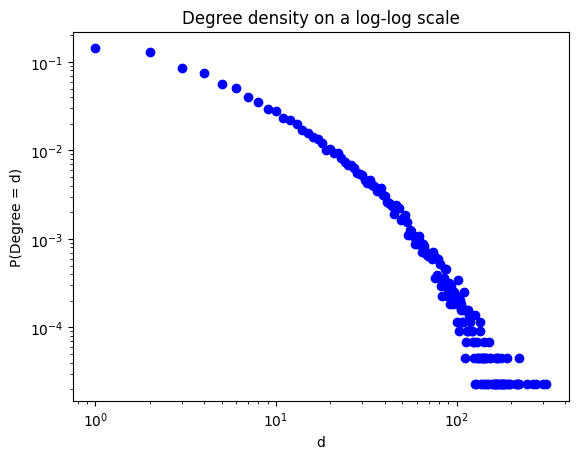

In [ ]:
# Degree density on a loglog scale
_ = plt.loglog(dd_h_bins[:-1], dd_h, 'bo') # with [:-1] we drop the last element: because bins are [1,2),[2,3), so we want to drop the last end point (plt.hist was handling it by itself)
_ = plt.xlabel("d")
_ = plt.ylabel("P(Degree = d)")
_ = plt.title("Degree density on a log-log scale")

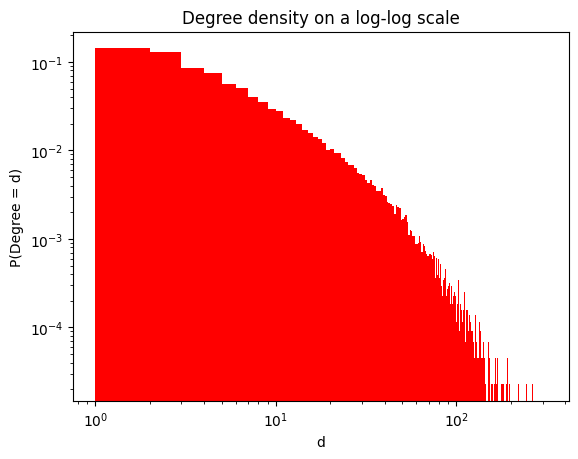

In [ ]:
# Default solutions for log-log scale do not plot in the same style we saw on the slides (plus the bin are linear!)
_ = plt.hist(fb_deg_list, bins=range(0,max(fb_deg_list)+1), density=True, color = 'red')
_ = plt.yscale('log')
_ = plt.xscale('log')
_ = plt.xlabel("d")
_ = plt.ylabel("P(Degree = d)")
_ = plt.title("Degree density on a log-log scale")

Let's move to computing the CDDF.

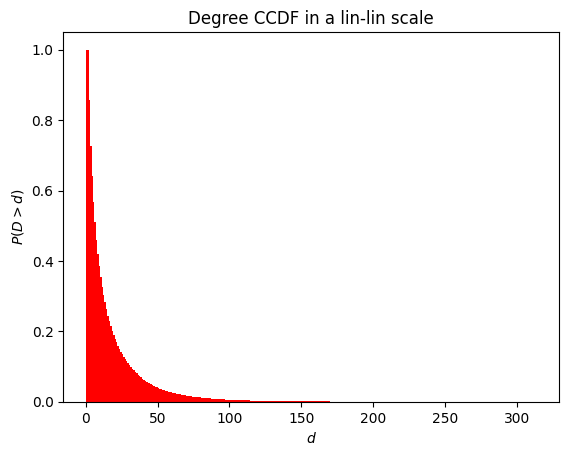

In [ ]:
# Compute the CCDF - we can use 2 ways
# 1. use the histogram functions with parameter cumulative=-1 gives the CCDF
dd_h, dd_h_bins, _ = plt.hist(fb_deg_list, bins=range(0,max(fb_deg_list)+1), density = True, color = 'red', cumulative = -1)
# _ = plt.axis([0,100,0,1])
_ = plt.xlabel("$d$")
_ = plt.ylabel("$P(D>d)$")
_ = plt.title("Degree CCDF in a lin-lin scale")

[34, 2, 15, 18]

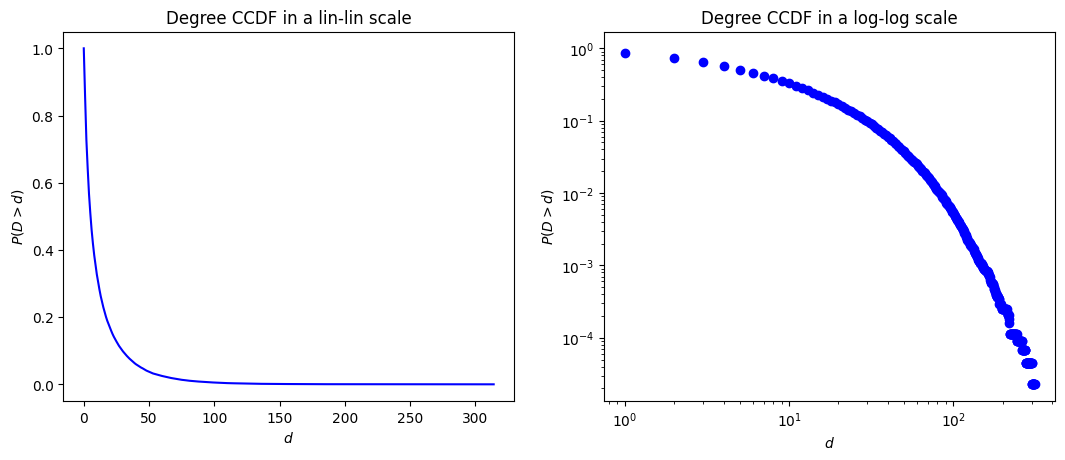

In [ ]:
# 2. More general: use the ECDF function of statsmodels.distributions.empirical_distribution
# ECDF(dataset) returns a the empirical CDF computed from the dataset, which can be used as a FUNCTION
# - i.e., it is possible to call ECDF(x) for any x, irrespective of the set of data from which the ECDF is derived

fb_deg_list[0:4]

deg_cdf = ECDF(fb_deg_list)

# scale the fig size twice in width
default_sizes = plt.rcParams["figure.figsize"] # rc stands for runtime configuration

fig_sizes = (2*default_sizes[0], default_sizes[1])

# generate a figure with 2 subplots, organised in 1 row and 2 columns
# ax1 and ax2 ("axes") are used to access the individual plots
# NB: in case of more rows, axes must be specified as list of lists, e.g., for 2x2 ((ax1,ax2),(ax3,ax4))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = fig_sizes)

# plot the CCDF in lin-lin and log-log scales
# see http://matplotlib.org/api/axes_api.html for the API of the Axis class
# see http://matplotlib.org/api/pyplot_api.html#matplotlib.pyplot.plot or the Axes.plot() documentation
# for the parameters of the plot method

degs = list(range(0,max(fb_deg_list)+1)) # note: range() returns a range object (an iterable of integers), while np.arange() returns a NumPy array.

_ = ax1.plot(degs, 1-deg_cdf(degs), 'b-') # means a blue (b) solid line (-)
_ = ax1.set_xlabel("$d$")
_ = ax1.set_ylabel("$P(D>d)$")
_ = ax1.set_title("Degree CCDF in a lin-lin scale")

_ = ax2.loglog(degs, 1-deg_cdf(degs), 'bo')
_ = ax2.set_xlabel("$d$")
_ = ax2.set_ylabel("$P(D>d)$")
_ = ax2.set_title("Degree CCDF in a log-log scale")

# Part 5. Fitting the degree distribution [optional]

## Power Laws

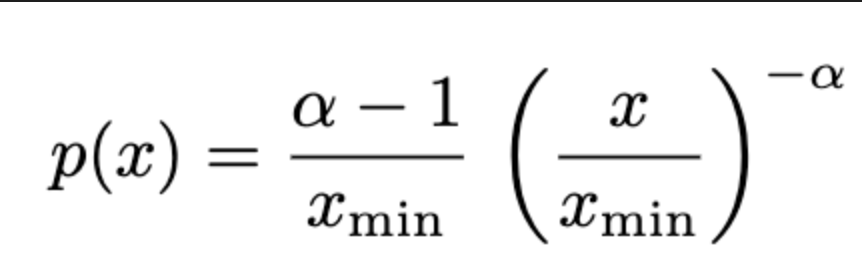

In [ ]:
# --- Empirical CDF ---
d_fb = list(dict(fb_GC_u.degree()).values()) # conversion to list needed for ECDF
fb_ecdf = ECDF(d_fb)

# --- Fit 1: manual xmin ---
xmin_manual = 10
fit_pl = powerlaw.Fit(d_fb, xmin=xmin_manual)

print(f"Manual xmin={xmin_manual}")
print(f"  PL  alpha : {fit_pl.power_law.alpha:.3f}")
print(f"  EXP lambda: {fit_pl.exponential.Lambda:.3f}")
print(f"  TPL alpha : {fit_pl.truncated_power_law.alpha:.3f}")
print(f"  TPL lambda: {fit_pl.truncated_power_law.Lambda:.3f}")

# --- Fit 2: automatic xmin (Clauset et al. paper) ---
fit_pl_auto = powerlaw.Fit(d_fb)

print(f"\nAuto xmin={int(fit_pl_auto.power_law.xmin)}")
print(f"  PL  alpha : {fit_pl_auto.power_law.alpha:.3f}")
print(f"  EXP lambda: {fit_pl_auto.exponential.Lambda:.3f}")
print(f"  TPL alpha : {fit_pl_auto.truncated_power_law.alpha:.3f}")
print(f"  TPL lambda: {fit_pl_auto.truncated_power_law.Lambda:.3f}")

Manual xmin=10
  PL  alpha : 2.541
  EXP lambda: 0.081
  TPL alpha : 1.472
  TPL lambda: 0.031
Calculating best minimal value for power law fit
xmin progress: 99%
Auto xmin=101
  PL  alpha : 6.753
  EXP lambda: 0.047
  TPL alpha : 6.754
  TPL lambda: 0.000


The code below is needed for the truncated powerlaw distribution, a hybrid between PL and exp, which captures real-life trends extremely well. You don't need to understand what the code does.

In [ ]:
from mpmath import gammainc

def tpl_ccdf_anchored(x_vals, alpha, lam, anchor, xmin):
    """
    Analytical TPL CCDF using upper incomplete gamma function.
    For TPL: p(x) ~ x^{-alpha} * exp(-lam*x)
    CCDF(x) = Gamma(1-alpha, lam*x) / Gamma(1-alpha, lam*xmin)
    anchored to empirical CCDF at xmin.
    """
    if lam < 1e-10:
        # degenerate case: TPL collapses to pure power law
        return anchor * (x_vals / xmin) ** (-(alpha - 1))
    
    s = 1 - alpha  # can be negative, mpmath handles this
    
    norm = float(gammainc(s, lam * xmin))
    if norm == 0:
        return np.zeros_like(x_vals, dtype=float)
    
    ccdf = np.array([float(gammainc(s, lam * k)) for k in x_vals])
    ccdf = np.clip(ccdf / norm, 0, 1)
    
    return anchor * ccdf

Let's plot all the curves.

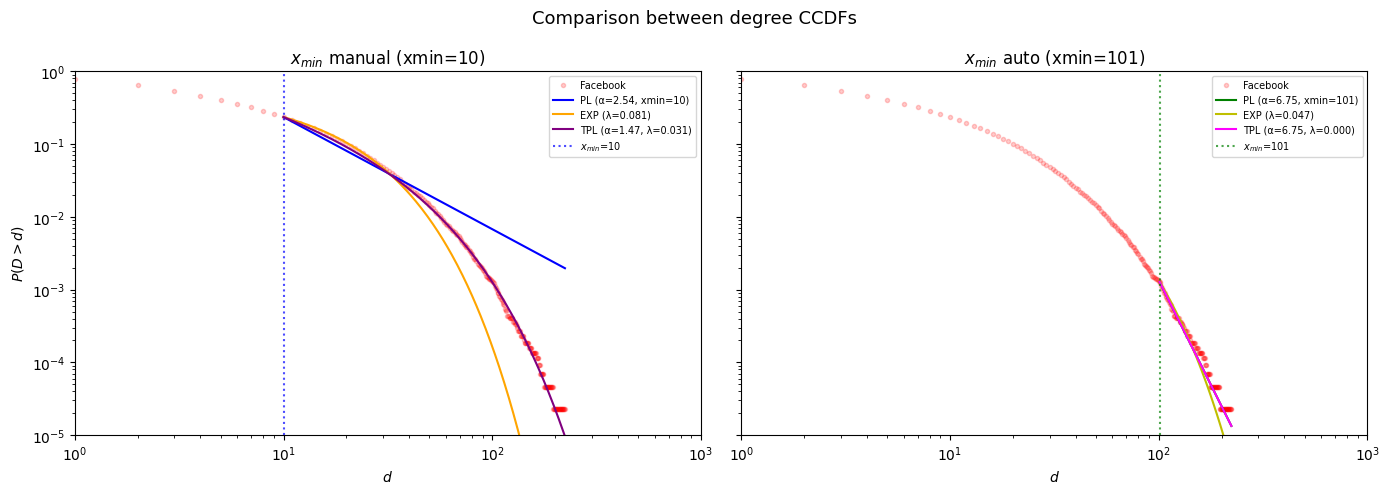

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True) # sharey=True -> subplots share the same y-axis scale

# the code below selects fit_pl (aka manual xmin) for the first plot axes[0], fit_pl_auto (aka auto xmin) for the second plot axes[1]. it also sets the colors of pl, exp, tpl
for ax, fit, label, color_pl, color_exp, color_tpl in [
    (axes[0], fit_pl,      'manual', 'b',      'orange',  'purple'),
    (axes[1], fit_pl_auto, 'auto',   'g',      'y',       'magenta'),
]:
    xmin = fit.power_law.xmin
    alpha = fit.power_law.alpha

    x = np.arange(1, max(d_fb) + 1) # entire x range
    x_tail = np.arange(int(xmin), max(d_fb) + 1, dtype=float) # x range after xmin
    anchor = 1 - fb_ecdf(xmin)  # empirical CCDF value at xmin

    # Anchoring: powerlaw's fitted distributions (power law, exponential, truncated power law) are all conditional distributions — 
    # they describe P(D>d∣D≥xmin), i.e., probabilities normalized so they equal 1 at xmin​. 
    # But the empirical CCDF we're plotting, 1 - fb_ecdf(x), is normalized over the whole dataset, so at x=xmin it equals whatever
    #  fraction of the full data is ≥xmin, not 1. The anchor value rescales the fitted curves to start from the CCDF at xmin

    # --- Empirical CCDF (full range) ---
    ax.loglog(x, 1 - fb_ecdf(x), 'ro', markersize=3, label='Facebook', alpha = 0.2)

    # --- Power law (anchored) ---
    pl = anchor * (x_tail / xmin) ** (-(alpha - 1)) # this is the CCDF [k/xmin)^^(-alpha+1)] rescaled by anchor
    ax.loglog(x_tail, pl, color=color_pl, label=f'PL (α={alpha:.2f}, xmin={int(xmin)})')

    # --- Exponential (anchored) ---
    lam_exp = fit.exponential.Lambda
    exp_fit = anchor * np.exp(-lam_exp * (x_tail - xmin)) # this is the CCDF [exp(-lambda*(k-xmin))] rescaled by anchor
    ax.loglog(x_tail, exp_fit, color=color_exp, label=f'EXP (λ={lam_exp:.3f})')

    # --- Truncated power law (anchored) ---
    alpha_tpl = fit.truncated_power_law.alpha
    lam_tpl = fit.truncated_power_law.Lambda
    tpl = tpl_ccdf_anchored(x_tail, alpha_tpl, lam_tpl, anchor, xmin)
    ax.loglog(x_tail, tpl, color=color_tpl, label=f'TPL (α={alpha_tpl:.2f}, λ={lam_tpl:.3f})')

    # --- Vertical line at xmin ---
    ax.axvline(xmin, color=color_pl, linestyle=':', alpha=0.7, label=f'$x_{{min}}$={int(xmin)}')

    # --- Formatting ---
    ax.set_xlim(1, 1000)
    ax.set_ylim(0.00001, 1)
    ax.set_xlabel("$d$")
    ax.set_title(f"$x_{{min}}$ {label} (xmin={int(xmin)})")
    ax.legend(numpoints=1, fontsize=7)

axes[0].set_ylabel("$P(D>d)$")
fig.suptitle("Comparison between degree CCDFs", fontsize=13)
plt.tight_layout() # automatically adjusts the spacing between subplots
plt.show()
plt.close(); # suppresses the matplot lib garbage output

Below is the significance test of the fitting. 

In [ ]:
def interpret(R, p, dist1, dist2):
    preferred = dist1 if R > 0 else dist2
    other     = dist2 if R > 0 else dist1
    
    if p > 0.05:
        significance = "but not significant (cannot distinguish the two)"
    else:
        significance = "and significant"
    
    return f"R={R:+.3f}, p={p:.3f}  → {preferred} preferred over {other}, {significance}"

for fit, label in [(fit_pl, 'manual'), (fit_pl_auto, 'auto')]:
    R_exp,     p_exp     = fit.distribution_compare('power_law',  'exponential')
    R_tpl,     p_tpl     = fit.distribution_compare('power_law',  'truncated_power_law')
    R_exp_tpl, p_exp_tpl = fit.distribution_compare('exponential','truncated_power_law')
    
    print(f"\n=== xmin {label} (xmin={int(fit.power_law.xmin)}) ===")
    print(f"PL  vs EXP: {interpret(R_exp,     p_exp,     'PL',  'EXP')}")
    print(f"PL  vs TPL: {interpret(R_tpl,     p_tpl,     'PL',  'TPL')}")
    print(f"EXP vs TPL: {interpret(R_exp_tpl, p_exp_tpl, 'EXP', 'TPL')}")


=== xmin manual (xmin=10) ===
PL  vs EXP: R=-24.935, p=0.635  → EXP preferred over PL, but not significant (cannot distinguish the two)
PL  vs TPL: R=-381.378, p=0.000  → TPL preferred over PL, and significant
EXP vs TPL: R=-356.443, p=0.000  → TPL preferred over EXP, and significant

=== xmin auto (xmin=101) ===
PL  vs EXP: R=+1.067, p=0.313  → PL preferred over EXP, but not significant (cannot distinguish the two)
PL  vs TPL: R=+0.000, p=1.000  → PL preferred over TPL, but not significant (cannot distinguish the two)
EXP vs TPL: R=-1.067, p=0.313  → TPL preferred over EXP, but not significant (cannot distinguish the two)


Assuming nested distributions
Assuming nested distributions


# Part 6. Assortativity, clustering, centrality, path length

## Assortativity

In [ ]:
# we use the undirected graph: fb_GC_u

# Pearson correlation
# This is the same as nx.degree_assortativity_coefficient but uses the potentially faster scipy.stats.pearsonr function.
nx.degree_assortativity_coefficient(fb_GC_u)


0.2159784599100846

The Facebook network is assortative.

Now we perform the `k_nn` analysis.

In [ ]:
# for a node "i", it returns the average degree of neighbors [the output is a dict]
fb_knn = nx.average_neighbor_degree(fb_GC_u)
fb_knn

{'2': 21.91304347826087,
 '3': 23.0,
 '79': 19.90909090909091,
 '872': 23.666666666666668,
 '1043': 31.38095238095238,
 '1847': 17.037037037037038,
 '3306': 29.448275862068964,
 '3372': 41.23809523809524,
 '4605': 24.794871794871796,
 '5402': 25.589285714285715,
 '5875': 29.8,
 '8785': 17.74074074074074,
 '10609': 15.96774193548387,
 '10998': 20.6,
 '11186': 15.473684210526315,
 '12172': 15.071428571428571,
 '17766': 14.454545454545455,
 '18086': 21.0,
 '18745': 13.153846153846153,
 '30579': 23.0,
 '42558': 23.8,
 '5': 18.44,
 '27': 22.7,
 '108': 13.333333333333334,
 '129': 24.3,
 '207': 20.135593220338983,
 '660': 13.555555555555555,
 '1210': 25.4,
 '1509': 45.660377358490564,
 '1560': 20.0,
 '2972': 15.833333333333334,
 '4471': 11.88888888888889,
 '4879': 9.2,
 '5145': 9.666666666666666,
 '5922': 20.59722222222222,
 '6066': 28.463414634146343,
 '6644': 21.214285714285715,
 '7640': 27.75,
 '11201': 29.954545454545453,
 '13180': 11.333333333333334,
 '24682': 21.142857142857142,
 '27156

In [ ]:
# it returns the average of the average degree of neighbors for all nodes with degree k (for all k values in the graph)
# the output is a dict { degree_k : average_of_average_degree_of_neighbors}
fb_knnk = nx.average_degree_connectivity(fb_GC_u)

fb_knnk

{23: 26.92687747035573,
 1: 14.32061394159028,
 11: 21.57797722447404,
 12: 22.458638211382112,
 21: 27.240593768371546,
 27: 28.074074074074073,
 29: 28.175802272274268,
 39: 31.98417220639443,
 56: 37.58620689655172,
 35: 30.900150375939848,
 31: 29.946599825632084,
 5: 16.836577708006278,
 19: 25.295055821371612,
 14: 21.99565122852794,
 17: 24.103953322219574,
 13: 22.629900402627676,
 3: 15.124048534177406,
 25: 27.20141592920354,
 10: 20.527155963302754,
 59: 33.05546995377504,
 9: 20.24163372859025,
 53: 32.51839622641509,
 20: 25.946174863387977,
 6: 17.961738002594032,
 72: 36.206944444444446,
 41: 32.928796223446106,
 4: 16.357374631268435,
 22: 26.83724340175953,
 48: 31.803571428571427,
 8: 19.906650071123757,
 16: 24.354417670682732,
 37: 33.65445819651427,
 69: 36.62977602108037,
 2: 14.453427483338622,
 24: 26.97642118863049,
 63: 34.628571428571426,
 57: 32.86124401913876,
 28: 28.504270186335404,
 15: 24.237997724687144,
 40: 30.58345588235294,
 7: 18.672394043528065,


Now we plot $k_{nn,i}$ and $k_{nn}(k)$

[23, 1, 11, 12, 21]

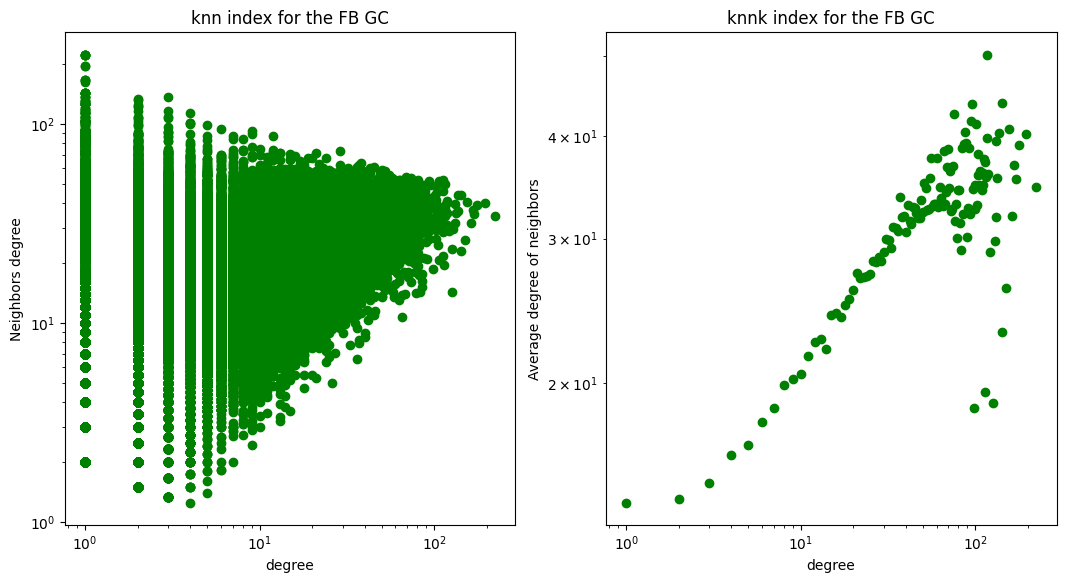

In [ ]:
# for k_nn,i we need degree_of_node_i vs k_nn,i
deg_list = [x[1] for x in list(fb_GC_u.degree())] # returns a list [ degree_first node, degree_second_node, etc.]
deg_list[0:5]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (2*default_sizes[0], default_sizes[0])) # prepare for plotting two plots side by side
_ = ax1.loglog(deg_list, fb_knn.values(), 'og')
_ = ax1.set_xlabel("degree")
_ = ax1.set_ylabel("Neighbors degree")
_ = ax1.set_title("knn index for the FB GC")

_ = ax2.loglog(fb_knnk.keys(), fb_knnk.values(), 'og')
_ = ax2.set_xlabel("degree")
_ = ax2.set_ylabel("Average degree of neighbors")
_ = ax2.set_title("knnk index for the FB GC")



The knn increases as k increases, so the network is assortative.

## Clustering

In [ ]:
# global clustering coefficient
nx.transitivity(fb_GC_u)

# local clustering coefficient
nx.average_clustering(fb_GC_u)

# to get the local clustering coefficient of individual nodes
local_clust = nx.clustering(fb_GC_u)
#dict(list(local_clust.items())[:5]) # local_clust is a dict, we do this just for printing

# if we take the mean of local_clust, we get exactly nx.average_clustering(fb_GC_u) [as expected]
np.mean(list(local_clust.values())) # conversion from dict().values() to list() is needed by np.mean

0.08509450365234017

0.114947594862054

0.11494759486205539

In [ ]:
local_clust

{'2': 0.1067193675889328,
 '3': 0,
 '79': 0.03636363636363636,
 '872': 0.15151515151515152,
 '1043': 0.02857142857142857,
 '1847': 0.03418803418803419,
 '3306': 0.05172413793103448,
 '3372': 0.03333333333333333,
 '4605': 0.06342780026990553,
 '5402': 0.11038961038961038,
 '5875': 0.07899159663865546,
 '8785': 0.09971509971509972,
 '10609': 0.053763440860215055,
 '10998': 0.2,
 '11186': 0.17543859649122806,
 '12172': 0.15384615384615385,
 '17766': 0.12727272727272726,
 '18086': 0.14705882352941177,
 '18745': 0.07692307692307693,
 '30579': 1.0,
 '42558': 0.3,
 '5': 0.08333333333333333,
 '27': 0.3111111111111111,
 '108': 0,
 '129': 0.28888888888888886,
 '207': 0.049678550555230856,
 '660': 0.1388888888888889,
 '1210': 0.1,
 '1509': 0.07619738751814223,
 '1560': 0.06315789473684211,
 '2972': 0,
 '4471': 0.1388888888888889,
 '4879': 0.022222222222222223,
 '5145': 0.06060606060606061,
 '5922': 0.03403755868544601,
 '6066': 0.05121951219512195,
 '6644': 0.06593406593406594,
 '7640': 1.0,
 '11

## Centrality

In [ ]:
v60 = [n for n in list(fb_GC_u.nodes) if fb_GC_u.degree(n) > 60]

sub_g = fb_GC_u.subgraph(v60)

print(f'Number of nodes in fb_GC_u = {fb_GC_u.number_of_nodes()} vs in selected subgraph = {sub_g.number_of_nodes()}')


Number of nodes in fb_GC_u = 43953 vs in selected subgraph = 356


In [ ]:
# degree centrality
deg_cent = dict(nx.degree(sub_g)) # covert to dict so it's in the same format as the other centralities

# closeness centrality
close_cent = nx.closeness_centrality(sub_g)

# betweenness centrality
bet_cent = nx.betweenness_centrality(sub_g)

The plots below show that centralities are correlated. A high X centrality typically corresponds to a large Y centrality, but the ranking is different. E.g., the node with the highest bet_cent is not the one with the highest close_cent.

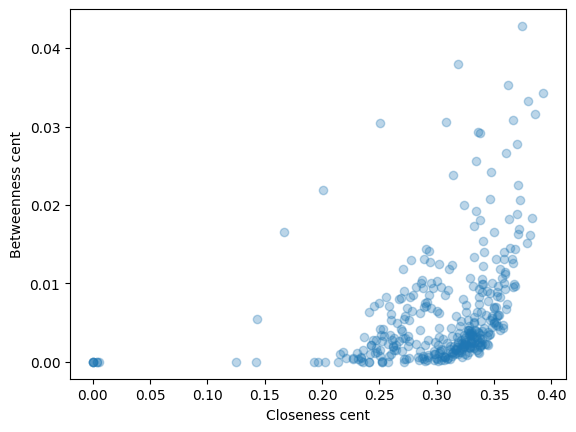

In [ ]:
_ = plt.scatter(close_cent.values(), list(bet_cent.values()), alpha=0.3)
_ = plt.xlabel("Closeness cent")
_ = plt.ylabel("Betweenness cent")

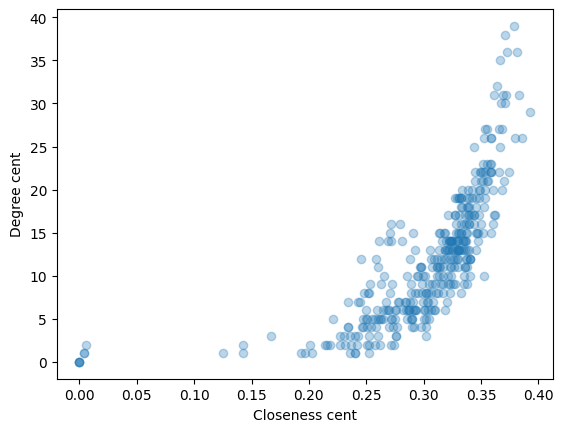

In [ ]:
_ = plt.scatter(close_cent.values(), list(deg_cent.values()), alpha=0.3)
_ = plt.xlabel("Closeness cent")
_ = plt.ylabel("Degree cent")

## Average path length

In [ ]:
src = sample(list(fb_GC_u.nodes), 1000)
trg = sample(list(fb_GC_u.nodes), 1000)

# it returns the number of hops
n_hops_u = [nx.shortest_path_length(fb_GC_u, source = src[i], target = trg[i]) for i in range(1000)]

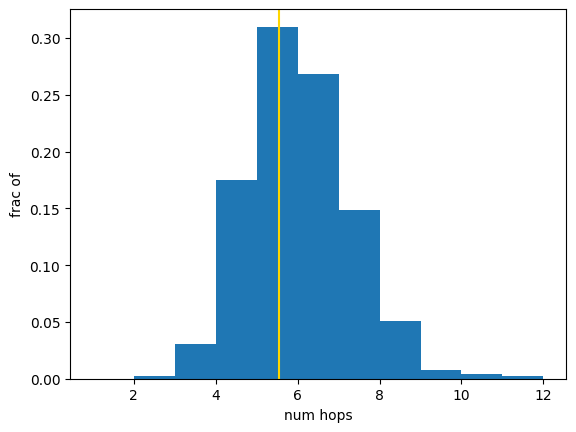

In [ ]:
_, _, _ = plt.hist(n_hops_u, bins = range(1, max(n_hops_u) + 2), density=True)
_ = plt.axvline(np.mean(n_hops_u), color = "gold")
_ = plt.xlabel("num hops")
_ = plt.ylabel("frac of")

The average number of hops is:

In [ ]:
np.mean(n_hops_u)

5.54

Now we compute the **weighted shortest path**, i.e., the path whose total sum of edge weights is smaller. First of all, let's define the "cost" of traversing an edge in a social network: it is inversely proportional to the tie strength.

In [ ]:
# WEIGHTED SHORTEST PATHS
# - weights in the dataset are the importance of the relationship,
#   while shortest paths assume this is a cost
# - so, use 1/weights as the cost of the shortest path computations
for e in fb_GC_u.edges():
    fb_GC_u.add_edge(*e, cost=1/fb_GC_u.edges[*e]['weight'])


Now we compute the weighted shorted path. The function `shortest_path_length` with `weight='cost'` computes the weighted number of hops (i.e., the sum of the weights on the links) of the weighted shorted path. We instead the number of hops (not weighted) of the weighted shortest path, to compare it against the length of the unweighted shortest path. So, we need to compute the path (with `shortest path`), and then we measure its length.

[11, 9, 15, 11]

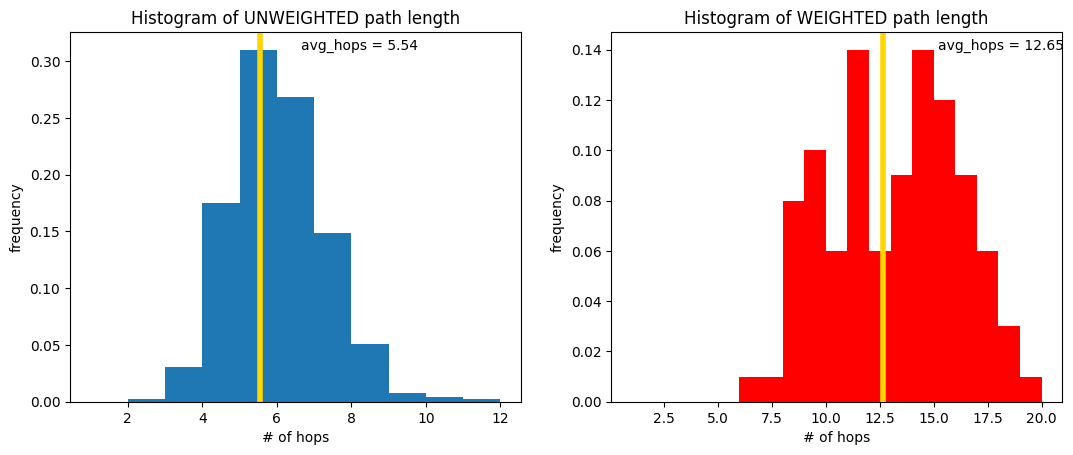

In [ ]:
# shortest_path_length returns the WEIGHTED NUMBER OF HOPS
# - instead, we want the number of hops on the shortest weighted path
n_hops_w = [len(nx.shortest_path(fb_GC_u, source = src[i], target = trg[i], weight='cost')) for i in range(100)]
n_hops_w[0:4]


# prepare for plotting the two distributions of shortest paths lengths
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (2*default_sizes[0], default_sizes[1]))

# plot the density and the average value (as a vertical line) of the unweighted distribution in the first plot
h_values,_,_ = ax1.hist(n_hops_u, bins = range(1,max(n_hops_u)+2), density = True)
mean_u_hops = np.mean(n_hops_u)
_ = ax1.axvline(mean_u_hops, color = 'gold', linewidth = 4)
_ = ax1.text(1.2*mean_u_hops, max(h_values), "avg_hops = %.2f" % mean_u_hops)
_ = ax1.set_xlabel("# of hops")
_ = ax1.set_ylabel("frequency")
_ = ax1.set_title("Histogram of UNWEIGHTED path length")

# plot the density and the average value (as a vertical line) of the weighted distribution in the second plot
h_values,_,_ = ax2.hist(n_hops_w, bins = range(1,max(n_hops_w)+2), density = True, color = 'red')
mean_w_hops = np.mean(n_hops_w)
_ = ax2.axvline(np.mean(n_hops_w), color = 'gold', linewidth = 4)
_ = ax2.text(1.2*mean_w_hops, max(h_values), "avg_hops = %.2f" % mean_w_hops)
_ = ax2.set_xlabel("# of hops")
_ = ax2.set_ylabel("frequency")
_ = ax2.set_title("Histogram of WEIGHTED path length")

# Part 7. Comparison with Equivalent Graphs

## Random graphs (ER)

According to the Erdős–Rényi model, a random graph is constructed by connecting nodes randomly with probability $p$.
We build an Erdős–Rényi model equivalent to the Facebook graph

- equivalence means the same number of nodes, and the same average degree (degree ~= pN)
    - thus, $p = \frac{\langle k \rangle}{N}$

In [ ]:
avg_degree = sum(dict(fb_GC_u.degree()).values())/fb_GC_u.number_of_nodes()
print(f'The average degree of the Facebook graph is {avg_degree}')

er_p_GC = avg_degree/fb_GC_u.number_of_nodes() # avg_degree / N
print(f'The p we set is {er_p_GC}')

er_fb_all = nx.erdos_renyi_graph(fb_GC_u.number_of_nodes(), er_p_GC)

# the resulting ER graph can be disconnected, so take only the Giant Component
er_fb = er_fb_all.subgraph(max(nx.connected_components(er_fb_all), key=len))

The average degree of the Facebook graph is 8.299046708984598
The p we set is 0.00018881638816427998


In [ ]:
print(f'Number of nodes in FB: {fb_GC_u.number_of_nodes()}')
print(f'Number of nodes in ER: {er_fb_all.number_of_nodes()}')
print(f'Number of nodes in ER (GC): {er_fb.number_of_nodes()}')

print(f'Number of edges in FB: {fb_GC_u.number_of_edges()}')
print(f'Number of edges in ER: {er_fb_all.number_of_edges()}')
print(f'Number of edges in ER (GC): {er_fb.number_of_edges()}')

print(f'Number of connected components in ER: {len(list(nx.connected_components(er_fb_all)))}')
sorted([len(cc) for cc in list(nx.connected_components(er_fb_all))], reverse=True)



Number of nodes in FB: 43953
Number of nodes in ER: 43953
Number of nodes in ER (GC): 43945
Number of edges in FB: 182384
Number of edges in ER: 182906
Number of edges in ER (GC): 182906
Number of connected components in ER: 9


[43945, 1, 1, 1, 1, 1, 1, 1, 1]

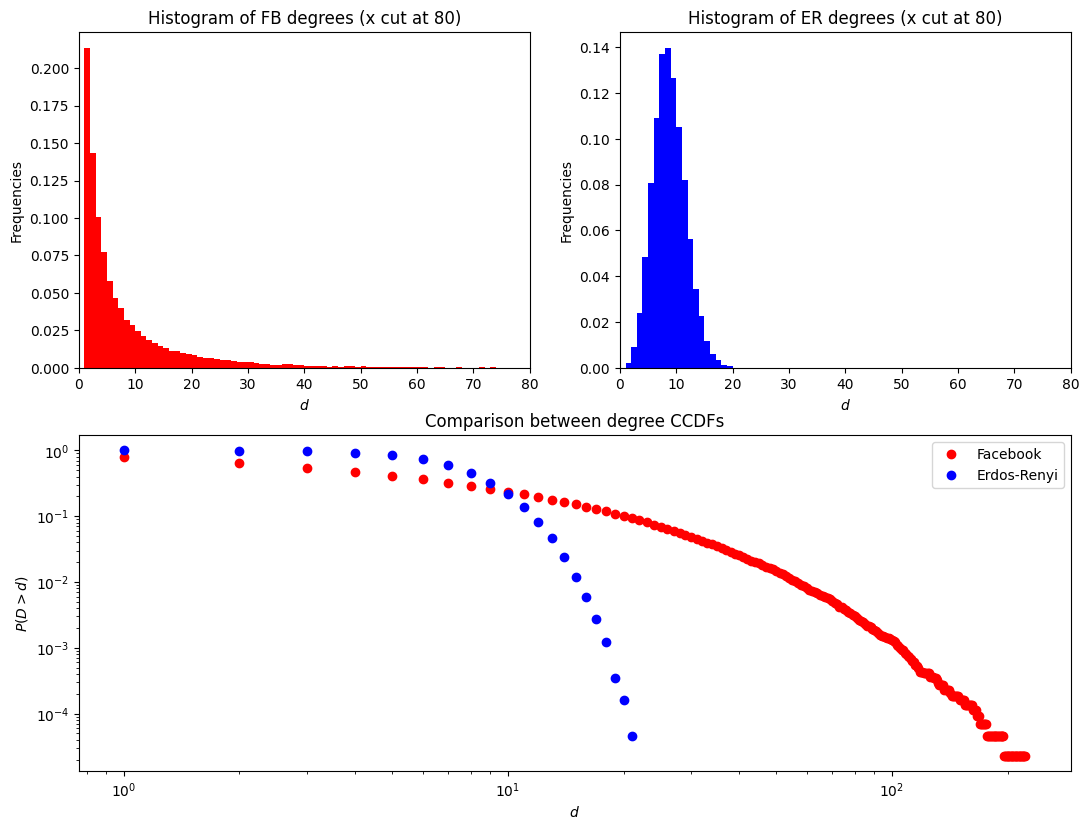

In [ ]:
# # we use GridSpecs for a finer control of the plot positioning
fig_sizes = (fig_sizes[0], 2*default_sizes[1])
f = plt.figure(figsize = fig_sizes)

# create a 2x2 Grid Specification
gs = gridspec.GridSpec(2, 2)

# add subplots to the figure, using the GridSpec gs
# position [0,0] (upper-left corner)
ax1 = plt.subplot(gs[0,0])
ax2 = plt.subplot(gs[0,1])
# the third plot spans the entire second row
ax3 = plt.subplot(gs[1,:])

# # compute and plot the histogram of FB degrees
d_fb = list(dict(fb_GC_u.degree()).values())
_,_,_ = ax1.hist(d_fb, bins=range(1,max(d_fb)+2), density = True, color = 'red')
_ = ax1.set_xlim(0,80)
_ = ax1.set_xlabel("$d$")
_ = ax1.set_ylabel("Frequencies")
_ = ax1.set_title("Histogram of FB degrees (x cut at 80)")

# # compute and plot the histogram of ER degrees
d_er = list(dict(er_fb.degree()).values())
_,_,_ = ax2.hist(d_er, bins=range(1,max(d_er)+2), density = True, color = 'blue')
_ = ax2.set_xlim(0,80)
_ = ax2.set_xlabel("$d$")
_ = ax2.set_ylabel("Frequencies")
_ = ax2.set_title("Histogram of ER degrees (x cut at 80)")

# compute and plot the degree CCDFs
fb_ecdf = ECDF(d_fb)
er_ecdf = ECDF(d_er)
x = np.arange(1,max(d_fb)+1)
_ = ax3.loglog(x, 1-fb_ecdf(x), 'ro', label = 'Facebook')
x = np.arange(1,max(d_er)+1)
_ = ax3.loglog(x, 1-er_ecdf(x), 'bo', label = 'Erdos-Renyi')
_ = ax3.set_xlabel("$d$")
_ = ax3.set_ylabel("$P(D>d)$")
_ = ax3.set_title("Comparison between degree CCDFs")
_ = ax3.legend(numpoints = 1)

### Assortativity

ER is neutral (nodes attach to others with the same probability regardless of their degree).

In [ ]:
print(f'Pearson FB = {nx.degree_pearson_correlation_coefficient(fb_GC_u):.3g} vs Pearson ER = {nx.degree_pearson_correlation_coefficient(er_fb):.3g}')
print('Pearson close to zero -> neutral')


Pearson FB = 0.216 vs Pearson ER = -0.00134
Pearson close to zero -> neutral


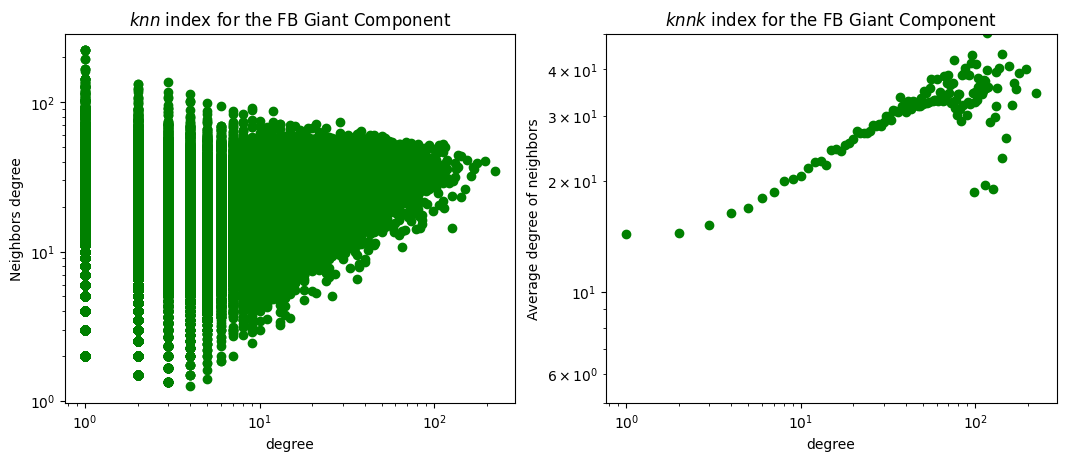

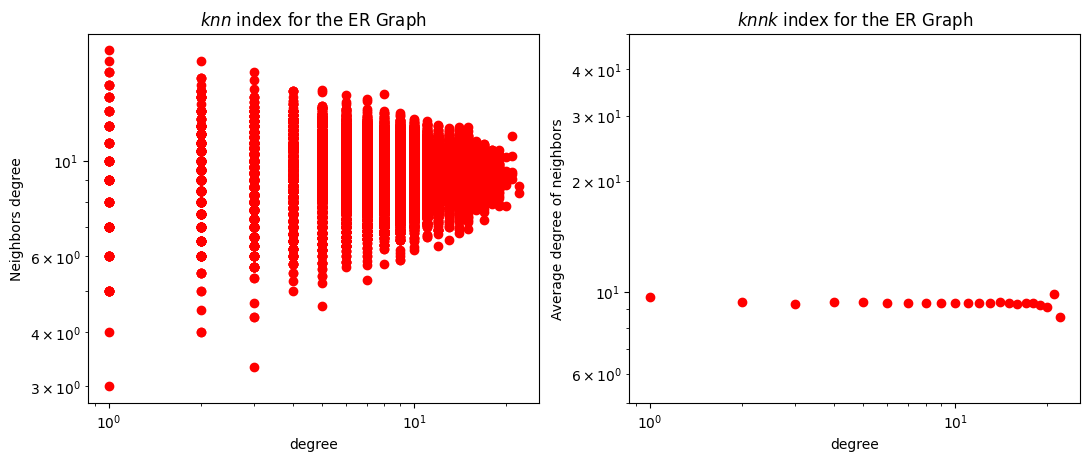

In [ ]:
###################
# The knn analysis 
###################

# average nearest neighbor degree for all vertices (knn)
fb_knn = nx.average_neighbor_degree(fb_GC_u)
# fb_knn

# average nearest neighbor degree of vertices with same degree value
fb_knnk = nx.average_degree_connectivity(fb_GC_u)
fb_knnk = dict(sorted(fb_knnk.items())) # not needed for plotting, just to get a nicer print
# fb_knnk

deg_list=[x[1] for x in list(fb_GC_u.degree())]

_ = fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (2*default_sizes[0], default_sizes[1]))
_ = ax1.loglog(deg_list, fb_knn.values(), 'go')
_ = ax1.set_xlabel("degree")
_ = ax1.set_ylabel("Neighbors degree")
_ = ax1.set_title("$knn$ index for the FB Giant Component")

_ = ax2.loglog(fb_knnk.keys(), fb_knnk.values(), 'go')
_ = ax2.set_ylim(5,50)
_ = ax2.set_xlabel("degree")
_ = ax2.set_ylabel("Average degree of neighbors")
_ = ax2.set_title("$knnk$ index for the FB Giant Component")


################################################################################################
# The knn analysis for ER

# average nearest neighbor degree for all vertices (knn)
er_knn = nx.average_neighbor_degree(er_fb)
# fb_knn

# average nearest neighbor degree of vertices with same degree value
er_knnk = nx.average_degree_connectivity(er_fb)
# er_knnk = dict(sorted(er_knnk.items())) # not needed for plotting, just to get a nicer print

er_deg_list=[x[1] for x in list(er_fb.degree())]

_ = fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (2*default_sizes[0], default_sizes[1]))
_ = ax1.loglog(er_deg_list, er_knn.values(), 'ro')
_ = ax1.set_xlabel("degree")
_ = ax1.set_ylabel("Neighbors degree")
_ = ax1.set_title("$knn$ index for the ER Graph")

_ = ax2.loglog(er_knnk.keys(), er_knnk.values(), 'ro')
_ = ax2.set_ylim(5,50)
_ = ax2.set_xlabel("degree")
_ = ax2.set_ylabel("Average degree of neighbors")
_ = ax2.set_title("$knnk$ index for the ER Graph")


### Clustering

In [ ]:
# clustering
print('FB clustering')
nx.transitivity(fb_GC_u) # global clustering (C1)
nx.average_clustering(fb_GC_u, count_zeros=True) # average local clustering (C2)

print('ER clustering')
nx.transitivity(er_fb) # global clustering (C1)
nx.average_clustering(er_fb, count_zeros=True) # average local clustering (C2)


FB clustering


0.08509450365234017

0.114947594862054

ER clustering


0.00016932567036229788

0.00019686822056763095

As expected, the ER graph has low clustering

### Shortest Path

In [ ]:
# Shortest path lenght
# on a subset of the nodes, as otherwise it will take forever to compute
# generated a sample of 100 vertices as source/destinations
fb_vs_src = sample(list(fb_GC_u.nodes()), 1000)
fb_vs_trg = sample(list(fb_GC_u.nodes()), 1000)
er_vs_src = sample(list(er_fb.nodes()), 1000)
er_vs_trg = sample(list(er_fb.nodes()), 1000)

# computed the UNWEIGHTED shortest paths
fb_n_hops_u = [nx.shortest_path_length(fb_GC_u, source = fb_vs_src[i], target = fb_vs_trg[i]) for i in range(1000)]
print(f'n hops FB = {np.mean(fb_n_hops_u)}')

er_n_hops_u = [nx.shortest_path_length(er_fb, source = er_vs_src[i], target = er_vs_trg[i]) for i in range(1000)]
print(f'n hops ER = {np.mean(er_n_hops_u)}')


n hops FB = 5.589
n hops ER = 5.247


As expected, the ER graph features the small world property.

## Random graphs (Watts-Strogatz)

ER graphs are not able to capture the following properties of many real-world graphs:
1. high clustering coefficient
2. power law degree

They do capture the small world effect (short averafe path length).

The Watts-Strogatz random graph has been proposed to address limitation 1.

According to the Watts-Strogatz model, the graph is constructed starting from a regular ring lattice (all nodes placed on a ring and each is connected to k neighbors, k/2 on each side -> k even). Then, for each node, each edge connecting to the k/2 rightmost neighbors is "rewired" with probability `p`. 

We build an Watts-Strogatz model roughly equivalent to the Facebook graph.

The equivalence we use:
- same `N`
- same average degree

__Note__: we know that `<k> = 2L/N`

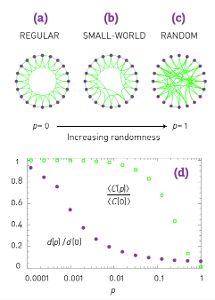

In [ ]:
avg_degree = sum(dict(fb_GC_u.degree()).values())/fb_GC_u.number_of_nodes()
avg_degree

int(avg_degree) # is it odd or even?

ws_fb_all = nx.watts_strogatz_graph(fb_GC_u.number_of_nodes(), k = int(avg_degree), p = 0.2) # note: if k is odd, k-1 is taken

# It is possible for the resulting graph to be disconnected, take only the Giant Component
ws_fb = ws_fb_all.subgraph(max(nx.connected_components(ws_fb_all), key=len))


8.299046708984598

8

In [ ]:
print(f'Number of nodes in FB: {fb_GC_u.number_of_nodes()}')
print(f'Number of nodes in WS: {ws_fb_all.number_of_nodes()}')
print(f'Number of nodes in WS (GC): {ws_fb.number_of_nodes()}')

print(f'Number of edges in FB: {fb_GC_u.number_of_edges()}')
print(f'Number of edges in WS: {ws_fb_all.number_of_edges()}')
print(f'Number of edges in WS (GC): {ws_fb.number_of_edges()}')

print(f'Number of connected components in WS: {len(list(nx.connected_components(ws_fb_all)))}')
sorted([len(cc) for cc in list(nx.connected_components(ws_fb_all))], reverse=True)

print(f'Avg Degree in FB: {np.mean(list(dict(fb_GC_u.degree()).values()))}') # conversion from dict().values() to list() is needed by np.mean
print(f'Avg Degree in WS: {np.mean(list(dict(ws_fb_all.degree()).values()))}') # conversion from dict().values() to list() is needed by np.mean
print(f'Avg Degree in WS (GC): {np.mean(list(dict(ws_fb.degree()).values()))}') # conversion from dict().values() to list() is needed by np.mean

Number of nodes in FB: 43953
Number of nodes in WS: 43953
Number of nodes in WS (GC): 43953
Number of edges in FB: 182384
Number of edges in WS: 175812
Number of edges in WS (GC): 175812
Number of connected components in WS: 1


[43953]

Avg Degree in FB: 8.299046708984598
Avg Degree in WS: 8.0
Avg Degree in WS (GC): 8.0


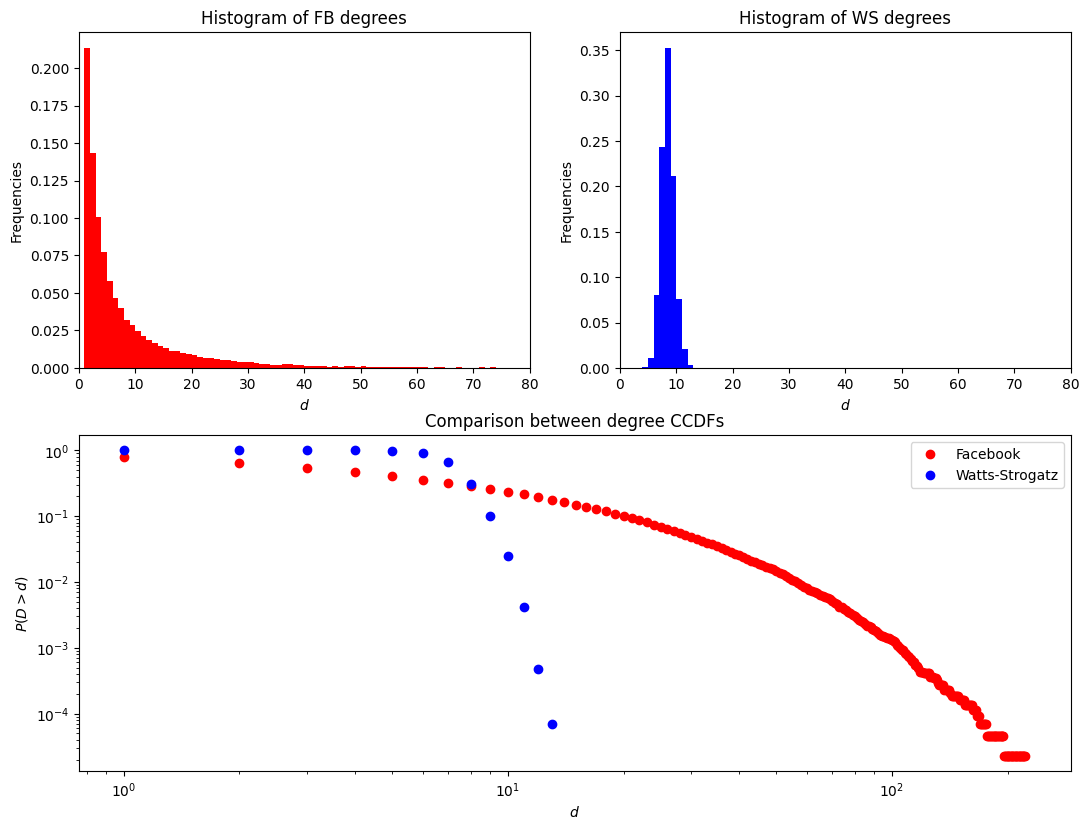

In [ ]:
# # we use GridSpecs for a finer control of the plot positioning
fig_sizes = (fig_sizes[0], 2*default_sizes[1])
f = plt.figure(figsize = fig_sizes)

# create a 2x2 Grid Specification
gs = gridspec.GridSpec(2, 2)

# add subplots to the figure, using the GridSpec gs
# position [0,0] (upper-left corner)
ax1 = plt.subplot(gs[0,0])
ax2 = plt.subplot(gs[0,1])
# the third plot spans the entire second row
ax3 = plt.subplot(gs[1,:])

# # compute and plot the histogram of FB degrees
d_fb = list(dict(fb_GC_u.degree()).values())
_,_,_ = ax1.hist(d_fb, bins=range(1,max(d_fb)+2), density = True, color = 'red')
_ = ax1.set_xlim(0,80)
_ = ax1.set_xlabel("$d$")
_ = ax1.set_ylabel("Frequencies")
_ = ax1.set_title("Histogram of FB degrees")

# # compute and plot the histogram of WS degrees
d_ws = list(dict(ws_fb.degree()).values())
_,_,_ = ax2.hist(d_ws, bins=range(1,max(d_ws)+2), density = True, color = 'blue')
_ = ax2.set_xlim(0,80)
_ = ax2.set_xlabel("$d$")
_ = ax2.set_ylabel("Frequencies")
_ = ax2.set_title("Histogram of WS degrees")

# compute and plot the degree CCDFs
fb_ecdf = ECDF(d_fb)
ws_ecdf = ECDF(d_ws)
x = np.arange(1,max(d_fb)+1)
_ = ax3.loglog(x, 1-fb_ecdf(x), 'ro', label = 'Facebook')
x = np.arange(1,max(d_ws)+1)
_ = ax3.loglog(x, 1-ws_ecdf(x), 'bo', label = 'Watts-Strogatz')
_ = ax3.set_xlabel("$d$")
_ = ax3.set_ylabel("$P(D>d)$")
_ = ax3.set_title("Comparison between degree CCDFs")
_ = ax3.legend(numpoints = 1)

### Assortativity

WS is neutral (nodes attach to others with the same probability regardless of their degree).

In [ ]:
# The global assortativity coefficient (Pearson)
nx.degree_pearson_correlation_coefficient(fb_GC_u)
nx.degree_pearson_correlation_coefficient(ws_fb)


0.21597845991024966

-0.024140482097118093

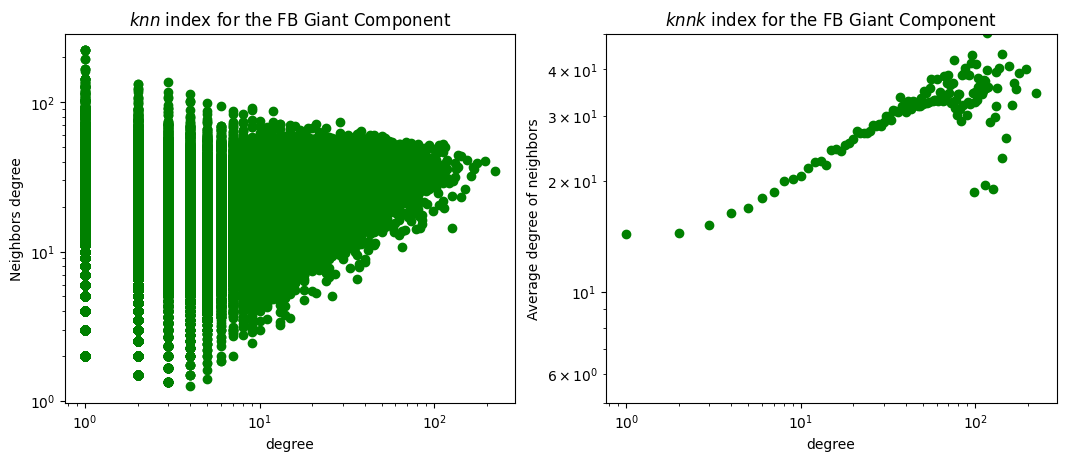

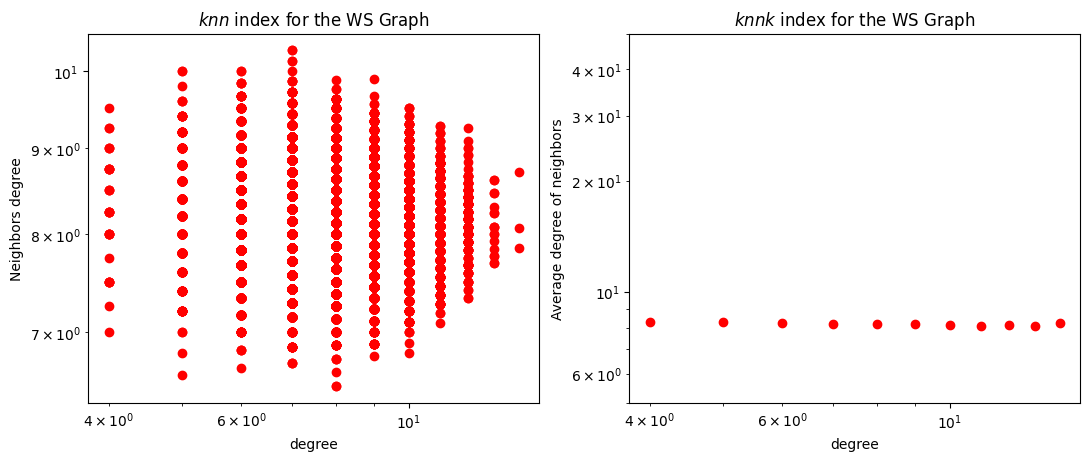

In [ ]:
###################
# The knn analysis 
###################

# average nearest neighbor degree for all vertices (knn)
fb_knn = nx.average_neighbor_degree(fb_GC_u)
# fb_knn

# average nearest neighbor degree of vertices with same degree value
fb_knnk = nx.average_degree_connectivity(fb_GC_u)
fb_knnk = dict(sorted(fb_knnk.items())) # not needed for plotting, just to get a nicer print
# fb_knnk

deg_list=[x[1] for x in list(fb_GC_u.degree())]

_ = fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (2*default_sizes[0], default_sizes[1]))
_ = ax1.loglog(deg_list, list(fb_knn.values()), 'go')
_ = ax1.set_xlabel("degree")
_ = ax1.set_ylabel("Neighbors degree")
_ = ax1.set_title("$knn$ index for the FB Giant Component")

_ = ax2.loglog(list(fb_knnk.keys()), list(fb_knnk.values()), 'go')
_ = ax2.set_ylim(5,50)
_ = ax2.set_xlabel("degree")
_ = ax2.set_ylabel("Average degree of neighbors")
_ = ax2.set_title("$knnk$ index for the FB Giant Component")

################################################################################################
# Equivalent WS graph

# average nearest neighbor degree for all vertices (knn)
ws_knn = nx.average_neighbor_degree(ws_fb)
# fb_knn

# average nearest neighbor degree of vertices with same degree value
ws_knnk = nx.average_degree_connectivity(ws_fb)
# er_knnk = dict(sorted(er_knnk.items())) # not needed for plotting, just to get a nicer print

ws_deg_list=[x[1] for x in list(ws_fb.degree())]

_ = fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (2*default_sizes[0], default_sizes[1]))
_ = ax1.loglog(ws_deg_list, list(ws_knn.values()), 'ro')
_ = ax1.set_xlabel("degree")
_ = ax1.set_ylabel("Neighbors degree")
_ = ax1.set_title("$knn$ index for the WS Graph")

_ = ax2.loglog(list(ws_knnk.keys()), list(ws_knnk.values()), 'ro')
_ = ax2.set_ylim(5,50)
_ = ax2.set_xlabel("degree")
_ = ax2.set_ylabel("Average degree of neighbors")
_ = ax2.set_title("$knnk$ index for the WS Graph")


### Clustering

In [ ]:
# clustering
nx.transitivity(fb_GC_u) # global transitivity (C1)
nx.average_clustering(fb_GC_u, count_zeros=True) # average local transitivity (C2)

nx.transitivity(ws_fb) # global transitivity (C1)
nx.average_clustering(ws_fb, count_zeros=True) # average local transitivity (C2)


0.08509450365234017

0.114947594862054

0.3201994088070639

0.33369760300346246

As expected, the WS graph has high clustering wrt the ER

### Shortest Path

In [ ]:
# Shortest path lenght
# on a subset of the nodes, as otherwise it will take forever to compute
# generated a sample of 100 vertices as source/destinations
fb_vs_src = sample(list(fb_GC_u.nodes()), 1000)
fb_vs_trg = sample(list(fb_GC_u.nodes()), 1000)
ws_vs_src = sample(list(ws_fb.nodes()), 1000)
ws_vs_trg = sample(list(ws_fb.nodes()), 1000)

# computed the UNWEIGHTED shortest paths
fb_n_hops_u = [nx.shortest_path_length(fb_GC_u, source = fb_vs_src[i], target = fb_vs_trg[i]) for i in range(1000)]
np.mean(fb_n_hops_u)

ws_n_hops_u = [nx.shortest_path_length(ws_fb, source = ws_vs_src[i], target = ws_vs_trg[i]) for i in range(1000)]
np.mean(ws_n_hops_u)


5.54

6.859

As expected, the WS graph features the small world property.

## Barabasi-Albert

BA graphs reproduce a power law degree distribution.

Equivalence:
- Same number of nodes
- `m` = number of edges / number of nodes


In [ ]:
ba_m = fb_GC_u.number_of_edges()/fb_GC_u.number_of_nodes()
ba_m

ba_fb_all = nx.barabasi_albert_graph(fb_GC_u.number_of_nodes(), m = int(ba_m)) # default: starts from a star graph on (m+1) nodes

# apart from degenerate cases, BA generates connected graphs. Still, the code below takes only the Giant Component
ba_fb = ba_fb_all.subgraph(max(nx.connected_components(ba_fb_all), key=len))

ba_fb.number_of_nodes()
fb_GC_u.number_of_nodes()

ba_fb.number_of_edges()
fb_GC_u.number_of_edges()

avg_degree
ba_fb.number_of_edges()/ba_fb.number_of_nodes()*2


4.149523354492299

43953

43953

175796

182384

8.299046708984598

7.999271949582509

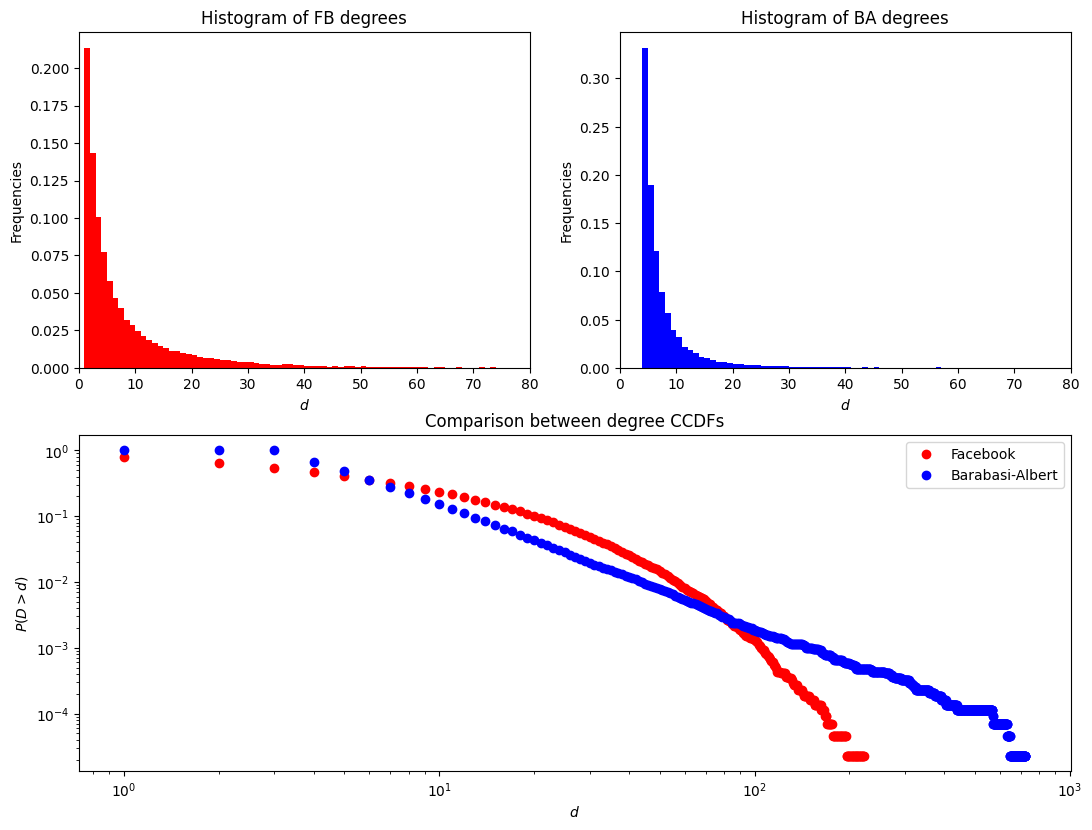

In [ ]:
# # we use GridSpecs for a finer control of the plot positioning
fig_sizes = (fig_sizes[0], 2*default_sizes[1])
f = plt.figure(figsize = fig_sizes)

# create a 2x2 Grid Specification
gs = gridspec.GridSpec(2, 2)

# add subplots to the figure, using the GridSpec gs
# position [0,0] (upper-left corner)
ax1 = plt.subplot(gs[0,0])
ax2 = plt.subplot(gs[0,1])
# the third plot spans the entire second row
ax3 = plt.subplot(gs[1,:])

# # compute and plot the histogram of FB degrees
d_fb = list(dict(fb_GC_u.degree()).values())
_,_,_ = ax1.hist(d_fb, bins=range(1,max(d_fb)+2), density = True, color = 'red')
_ = ax1.set_xlim(0,80)
_ = ax1.set_xlabel("$d$")
_ = ax1.set_ylabel("Frequencies")
_ = ax1.set_title("Histogram of FB degrees")

# # compute and plot the histogram of ER degrees
d_ba = list(dict(ba_fb.degree()).values())
_,_,_ = ax2.hist(d_ba, bins=range(1,max(d_ba)+2), density = True, color = 'blue')
_ = ax2.set_xlim(0,80)
_ = ax2.set_xlabel("$d$")
_ = ax2.set_ylabel("Frequencies")
_ = ax2.set_title("Histogram of BA degrees")

# compute and plot the degree CCDFs
fb_ecdf = ECDF(d_fb)
ba_ecdf = ECDF(d_ba)
x = np.arange(1,max(d_fb)+1)
_ = ax3.loglog(x, 1-fb_ecdf(x), 'ro', label = 'Facebook')
x = np.arange(1,max(d_ba)+1)
_ = ax3.loglog(x, 1-ba_ecdf(x), 'bo', label = 'Barabasi-Albert')
_ = ax3.set_xlabel("$d$")
_ = ax3.set_ylabel("$P(D>d)$")
_ = ax3.set_title("Comparison between degree CCDFs")
_ = ax3.legend(numpoints = 1)

### Assortativity

In general, BA is disassortative because:
- When a new node joins, it adds exactly m edges (m is fixed for the whole graph). So every node, at the moment it enters the network, has degree m: it's a "low-degree" node by construction.
- The new node's m edges are more likely to land on nodes that already have high degree (the "rich get richer" mechanism)
- Hubs rarely connect to each other. Two nodes can only become mutual hubs if they both arrived early. But once two early nodes are both large, there's no ongoing mechanism that specifically links high-degree nodes together.

However, when running the Pearson correlation (see below), it comes only slightly negative and close to zero.

In [ ]:
# The global assortativity coefficient (Pearson)
nx.degree_pearson_correlation_coefficient(fb_GC_u)
nx.degree_pearson_correlation_coefficient(ba_fb)

0.21597845991024966

-0.021128284150590735

The reason is that Pearson's r is normalized by variance, and BA has enormous degree variance. The knn shows the disassortativity more clearly.

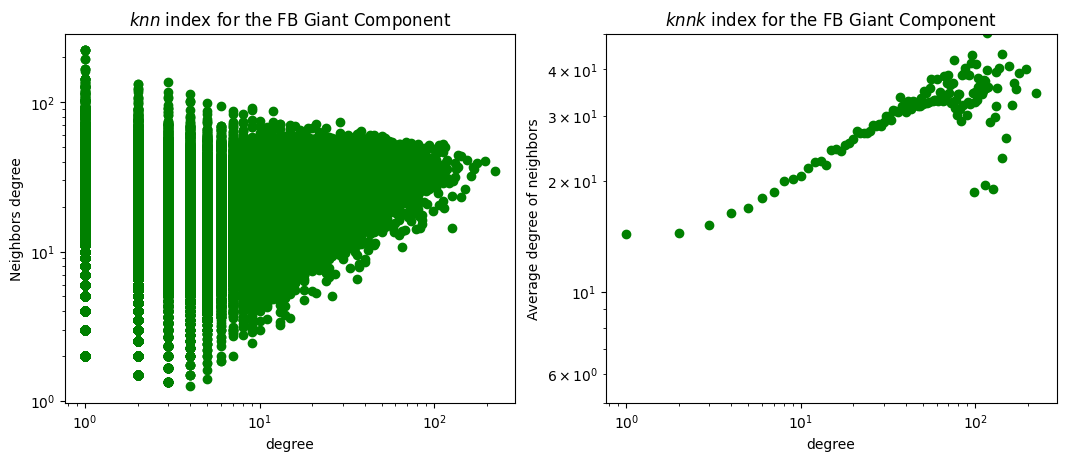

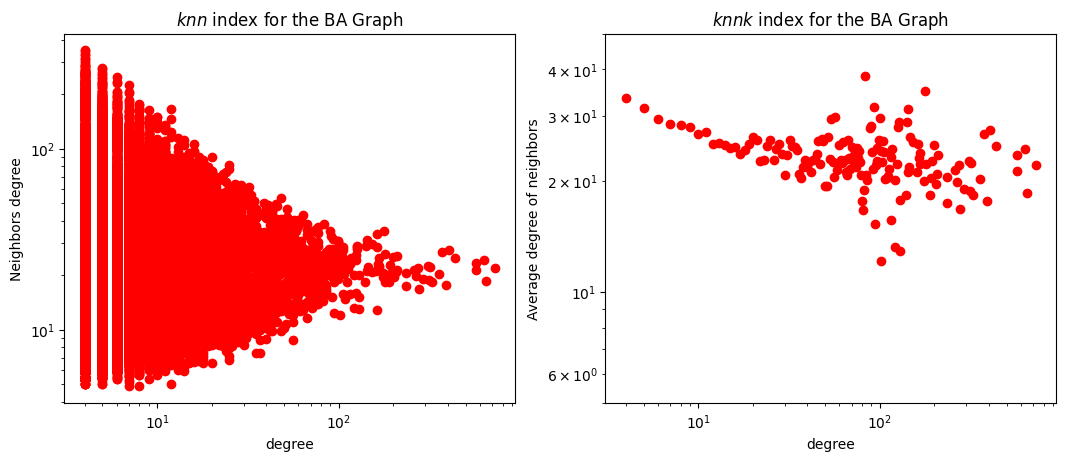

In [ ]:
###################
# The knn analysis 
###################

# average nearest neighbor degree for all vertices (knn)
fb_knn = nx.average_neighbor_degree(fb_GC_u)
# fb_knn

# average nearest neighbor degree of vertices with same degree value
fb_knnk = nx.average_degree_connectivity(fb_GC_u)
fb_knnk = dict(sorted(fb_knnk.items())) # not needed for plotting, just to get a nicer print
# fb_knnk

deg_list=[x[1] for x in list(fb_GC_u.degree())]

_ = fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (2*default_sizes[0], default_sizes[1]))
_ = ax1.loglog(deg_list, list(fb_knn.values()), 'go')
_ = ax1.set_xlabel("degree")
_ = ax1.set_ylabel("Neighbors degree")
_ = ax1.set_title("$knn$ index for the FB Giant Component")

_ = ax2.loglog(list(fb_knnk.keys()), list(fb_knnk.values()), 'go')
_ = ax2.set_ylim(5,50)
_ = ax2.set_xlabel("degree")
_ = ax2.set_ylabel("Average degree of neighbors")
_ = ax2.set_title("$knnk$ index for the FB Giant Component")

################################################################################################
# Equivalent BA graph

# The knn analysis 
# average nearest neighbor degree for all vertices (knn)
ba_knn = nx.average_neighbor_degree(ba_fb)
# fb_knn

# average nearest neighbor degree of vertices with same degree value
ba_knnk = nx.average_degree_connectivity(ba_fb)
# er_knnk = dict(sorted(er_knnk.items())) # not needed for plotting, just to get a nicer print

ba_deg_list=[x[1] for x in list(ba_fb.degree())]

_ = fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (2*default_sizes[0], default_sizes[1]))
_ = ax1.loglog(ba_deg_list, ba_knn.values(), 'ro')
_ = ax1.set_xlabel("degree")
_ = ax1.set_ylabel("Neighbors degree")
_ = ax1.set_title("$knn$ index for the BA Graph")

_ = ax2.loglog(ba_knnk.keys(), ba_knnk.values(), 'ro')
_ = ax2.set_ylim(5,50)
_ = ax2.set_xlabel("degree")
_ = ax2.set_ylabel("Average degree of neighbors")
_ = ax2.set_title("$knnk$ index for the BA Graph")


### Clustering

In [ ]:
# clustering
nx.transitivity(fb_GC_u) # global transitivity (C1)
nx.average_clustering(fb_GC_u, count_zeros=True) # average local transitivity (C2)

nx.transitivity(ba_fb) # global transitivity (C1)
nx.average_clustering(ba_fb, count_zeros=True) # average local transitivity (C2)


0.08509450365234017

0.114947594862054

0.0011596773621766017

0.0019733153806327196

As expected, the BA graph has a low clustering coefficient.

### Shortest Path

In [ ]:
# Shortest path lenght
# on a subset of the nodes, as otherwise it will take forever to compute
# generated a sample of 100 vertices as source/destinations
fb_vs_src = sample(list(fb_GC_u.nodes()), 1000)
fb_vs_trg = sample(list(fb_GC_u.nodes()), 1000)
ba_vs_src = sample(list(ba_fb.nodes()), 1000)
ba_vs_trg = sample(list(ba_fb.nodes()), 1000)

# computed the UNWEIGHTED shortest paths
fb_n_hops_u = [nx.shortest_path_length(fb_GC_u, source = fb_vs_src[i], target = fb_vs_trg[i]) for i in range(1000)]
np.mean(fb_n_hops_u)

ba_n_hops_u = [nx.shortest_path_length(ba_fb, source = ba_vs_src[i], target = ba_vs_trg[i]) for i in range(1000)]
np.mean(ba_n_hops_u)


5.654

4.332

As expected, the BA graph features the small world property.

## Configuration model

Generates a random graph with arbitrary degree distribution.

Input: the degree list itself.

In [ ]:

cm_fb_all = nx.configuration_model(list(dict(fb_GC_u.degree()).values()))
type(cm_fb_all)
cm_fb_all = nx.Graph(cm_fb_all) # remove multilinks by converting to nx.Graph
cm_fb_all.remove_edges_from(nx.selfloop_edges(cm_fb_all)) # remove self-loops

# The configuration model does not guarantee connectivity, so this is needed
cm_fb = cm_fb_all.subgraph(max(nx.connected_components(cm_fb_all), key=len))

cm_fb.number_of_nodes()
fb_GC_u.number_of_nodes()

cm_fb.number_of_edges()
fb_GC_u.number_of_edges()

avg_degree
cm_fb.number_of_edges()/cm_fb.number_of_nodes()*2


networkx.classes.multigraph.MultiGraph

43699

43953

182098

182384

8.299046708984598

8.334195290510081

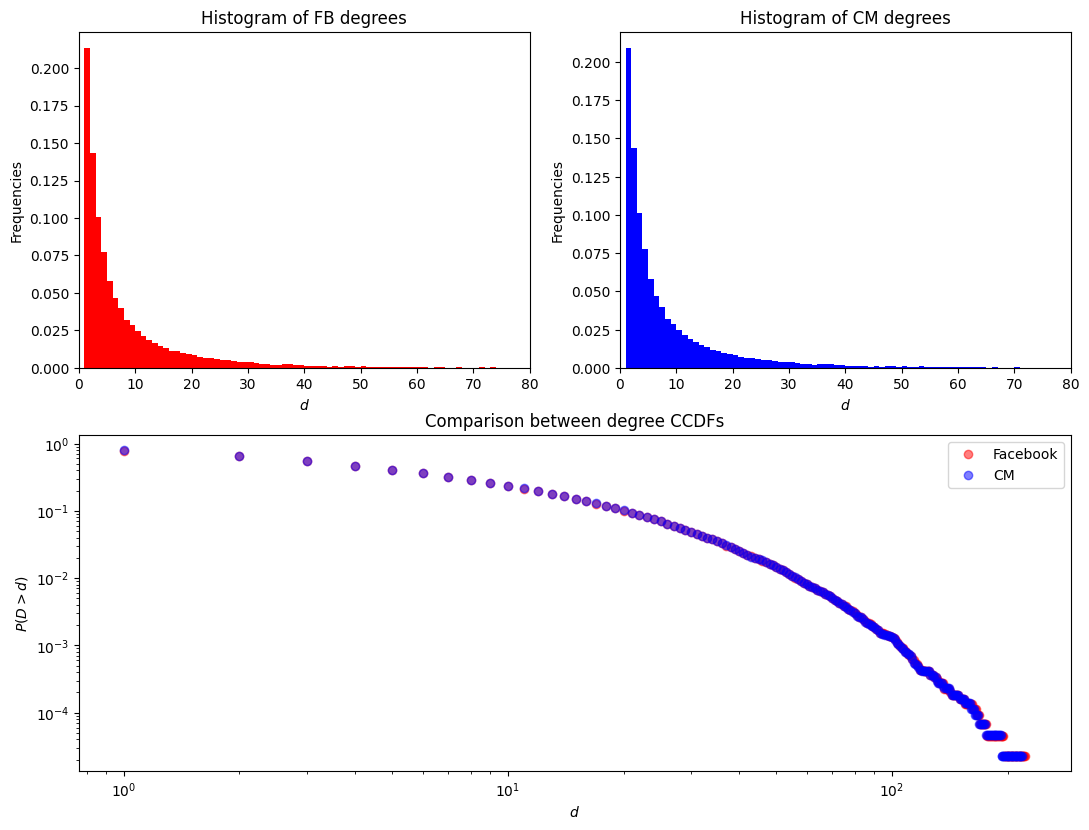

In [ ]:
# # we use GridSpecs for a finer control of the plot positioning
fig_sizes = (fig_sizes[0], 2*default_sizes[1])
f = plt.figure(figsize = fig_sizes)

# create a 2x2 Grid Specification
gs = gridspec.GridSpec(2, 2)

# add subplots to the figure, using the GridSpec gs
# position [0,0] (upper-left corner)
ax1 = plt.subplot(gs[0,0])
ax2 = plt.subplot(gs[0,1])
# the third plot spans the entire second row
ax3 = plt.subplot(gs[1,:])

# # compute and plot the histogram of FB degrees
d_fb = list(dict(fb_GC_u.degree()).values())
_,_,_ = ax1.hist(d_fb, bins=range(1,max(d_fb)+2), density = True, color = 'red')
_ = ax1.set_xlim(0,80)
_ = ax1.set_xlabel("$d$")
_ = ax1.set_ylabel("Frequencies")
_ = ax1.set_title("Histogram of FB degrees")

# # compute and plot the histogram of CM degrees
d_cm = list(dict(cm_fb.degree()).values()) # conversion to list needed for ECDF
_,_,_ = ax2.hist(d_cm, bins=range(1,max(d_cm)+2), density = True, color = 'blue')
_ = ax2.set_xlim(0,80)
_ = ax2.set_xlabel("$d$")
_ = ax2.set_ylabel("Frequencies")
_ = ax2.set_title("Histogram of CM degrees")

# compute and plot the degree CCDFs
fb_ecdf = ECDF(d_fb)
cm_ecdf = ECDF(d_cm)
x = np.arange(1,max(d_fb)+1)
_ = ax3.loglog(x, 1-fb_ecdf(x), 'ro', label = 'Facebook', alpha=0.5)
x = np.arange(1,max(d_cm)+1)
_ = ax3.loglog(x, 1-cm_ecdf(x), 'bo', label = 'CM', alpha = 0.5)
_ = ax3.set_xlabel("$d$")
_ = ax3.set_ylabel("$P(D>d)$")
_ = ax3.set_title("Comparison between degree CCDFs")
_ = ax3.legend(numpoints = 1)

### Assortativity

In [ ]:
# The global assortativity coefficient (Pearson)
nx.degree_pearson_correlation_coefficient(fb_GC_u)
nx.degree_pearson_correlation_coefficient(cm_fb)

0.21597845991024966

-0.0038251540781867686

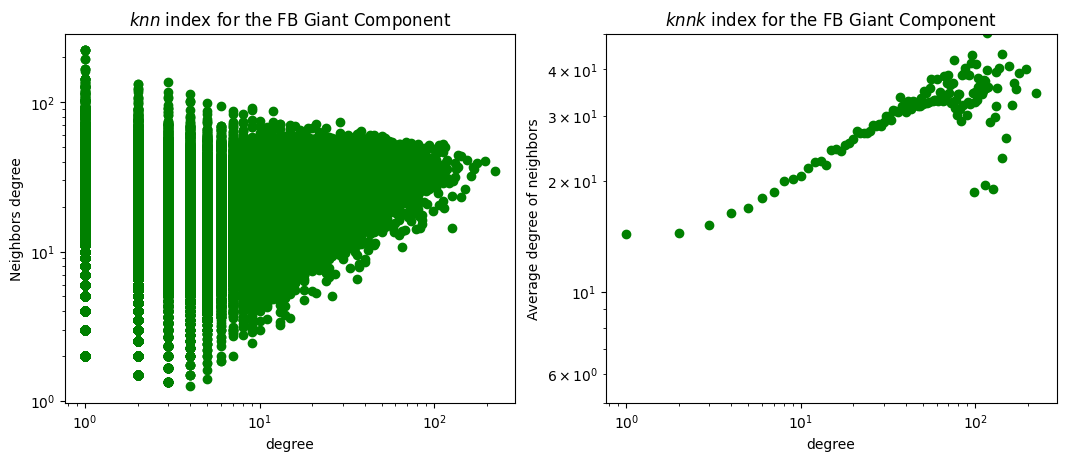

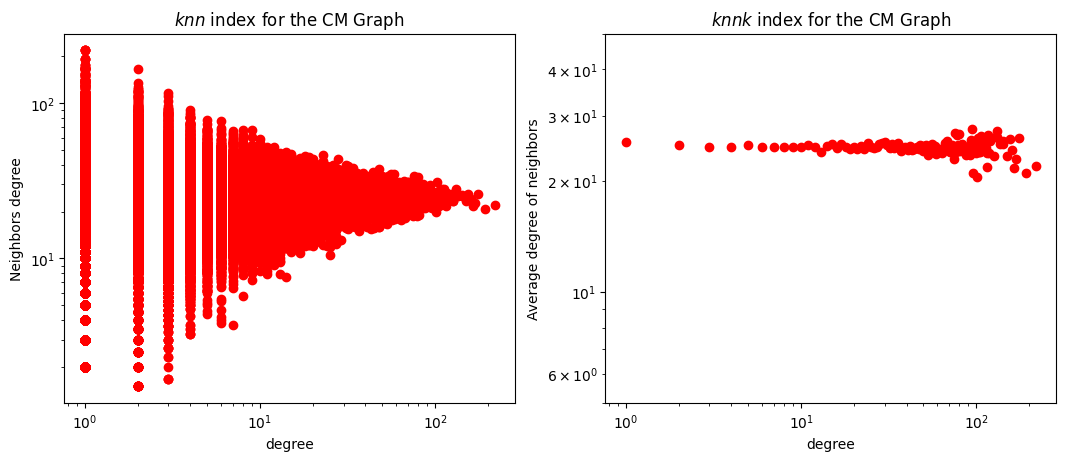

In [ ]:
###################
# The knn analysis 
###################

# average nearest neighbor degree for all vertices (knn)
fb_knn = nx.average_neighbor_degree(fb_GC_u)
# fb_knn

# average nearest neighbor degree of vertices with same degree value
fb_knnk = nx.average_degree_connectivity(fb_GC_u)
fb_knnk = dict(sorted(fb_knnk.items())) # not needed for plotting, just to get a nicer print
# fb_knnk

deg_list=[x[1] for x in list(fb_GC_u.degree())]

_ = fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (2*default_sizes[0], default_sizes[1]))
_ = ax1.loglog(deg_list, fb_knn.values(), 'go')
_ = ax1.set_xlabel("degree")
_ = ax1.set_ylabel("Neighbors degree")
_ = ax1.set_title("$knn$ index for the FB Giant Component")

_ = ax2.loglog(fb_knnk.keys(), fb_knnk.values(), 'go')
_ = ax2.set_ylim(5,50)
_ = ax2.set_xlabel("degree")
_ = ax2.set_ylabel("Average degree of neighbors")
_ = ax2.set_title("$knnk$ index for the FB Giant Component")

################################################################################################
# Equivalent CM graph

# average nearest neighbor degree for all vertices (knn)
cm_knn = nx.average_neighbor_degree(cm_fb)
# fb_knn

# average nearest neighbor degree of vertices with same degree value
cm_knnk = nx.average_degree_connectivity(cm_fb)

cm_deg_list=[x[1] for x in list(cm_fb.degree())]

_ = fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (2*default_sizes[0], default_sizes[1]))
_ = ax1.loglog(cm_deg_list, cm_knn.values(), 'ro')
_ = ax1.set_xlabel("degree")
_ = ax1.set_ylabel("Neighbors degree")
_ = ax1.set_title("$knn$ index for the CM Graph")

_ = ax2.loglog(cm_knnk.keys(), cm_knnk.values(), 'ro')
_ = ax2.set_ylim(5,50)
_ = ax2.set_xlabel("degree")
_ = ax2.set_ylabel("Average degree of neighbors")
_ = ax2.set_title("$knnk$ index for the CM Graph")


### Clustering

In [ ]:
# clustering
nx.transitivity(fb_GC_u) # global transitivity (C1)
nx.average_clustering(fb_GC_u, count_zeros=True) # average local transitivity (C2)

nx.transitivity(cm_fb) # global transitivity (C1)
nx.average_clustering(cm_fb, count_zeros=True) # average local transitivity (C2)


0.08509450365234017

0.114947594862054

0.001559540662085154

0.0012446531561764102

As expected, the CM graph has a low clustering coefficient.

### Shortest Path

In [ ]:
# Shortest path lenght
# on a subset of the nodes, as otherwise it will take forever to compute
# generated a sample of 100 vertices as source/destinations
fb_vs_src = sample(list(fb_GC_u.nodes()), 1000)
fb_vs_trg = sample(list(fb_GC_u.nodes()), 1000)
cm_vs_src = sample(list(cm_fb.nodes()), 1000)
cm_vs_trg = sample(list(cm_fb.nodes()), 1000)

# computed the UNWEIGHTED shortest paths
fb_n_hops_u = [nx.shortest_path_length(fb_GC_u, source = fb_vs_src[i], target = fb_vs_trg[i]) for i in range(1000)]
np.mean(fb_n_hops_u)

cm_n_hops_u = [nx.shortest_path_length(cm_fb, source = cm_vs_src[i], target = cm_vs_trg[i]) for i in range(1000)]
np.mean(cm_n_hops_u)


5.572

4.54

As expected, the CM graph features the small world property.

# Part 8. Manipulating graphs

Vertices and edges can be added/removed.

We use a small toy graph as example, stored in NCOL format in $\tt{./toy\_graph.ncol}$

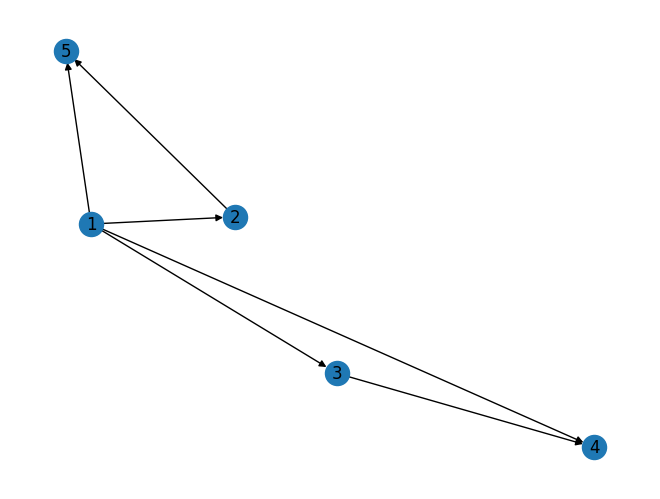

In [ ]:
toy_g = nx.read_weighted_edgelist("./toy_graph.ncol", create_using=nx.DiGraph)
nx.draw(toy_g, with_labels = True)

### Adding/removing Vertices

In [ ]:
toy_g.nodes

# Add two nodes whose names are "6" and "7"
toy_g.add_nodes_from(["6","7"])

# Add one node whose name is "8"
toy_g.add_node("8")
toy_g.add_node("8") # this is ignored because node "8" already exists

toy_g.nodes

NodeView(('1', '2', '3', '4', '5'))

NodeView(('1', '2', '3', '4', '5', '6', '7', '8'))

__Notes__

Multiple nodes with the same name CANNOT exist (they are not entered by `networkx`)

In [ ]:
toy_g.nodes

# Remove two nodes whose names are "6" and "7"
toy_g.remove_nodes_from(["6","7"])

# Remove one node whose name is "8"
toy_g.remove_node("8")

toy_g.nodes

NodeView(('1', '2', '3', '4', '5', '6', '7', '8'))

NodeView(('1', '2', '3', '4', '5'))

In [ ]:
# cannot remove vertices by index - There is no built-in notion of, e.g., the 5-th node, because graphs are not ordered arrays.
# toy_g.remove_node(0) # this FAILS!

### Adding Edges

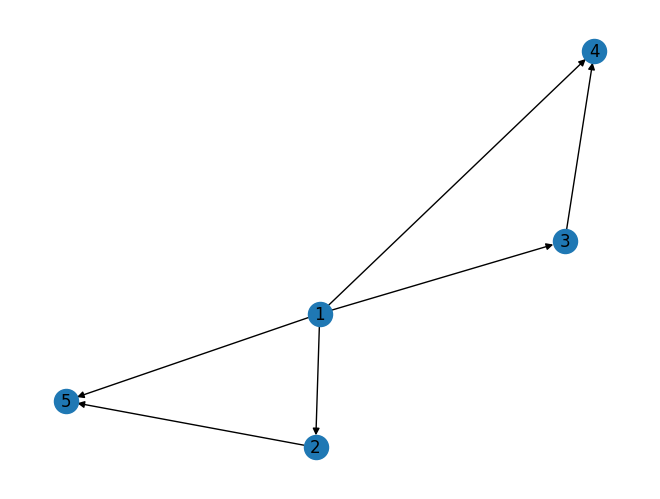

In [ ]:
# let's reload the graph from scratch, to start from a clean situation
toy_g = nx.read_weighted_edgelist("./toy_graph.ncol", create_using=nx.DiGraph)
nx.draw(toy_g, with_labels = True)


OutEdgeDataView([('1', '2', {'weight': 0.1}), ('1', '3', {'weight': 0.3}), ('1', '4', {'weight': 0.01}), ('1', '5', {'weight': 0.5}), ('2', '5', {'weight': 1.0}), ('3', '4', {'weight': 0.9})])

OutEdgeDataView([('1', '2', {'weight': 0.1}), ('1', '3', {'weight': 0.3}), ('1', '4', {'weight': 0.01}), ('1', '5', {'weight': 0.5}), ('2', '5', {'weight': 1.0}), ('3', '4', {'weight': 0.9}), ('5', 'a', {'weight': 0.03}), ('a', 'b', {'weight': 0.02}), ('b', 'a', {'weight': 0.01})])

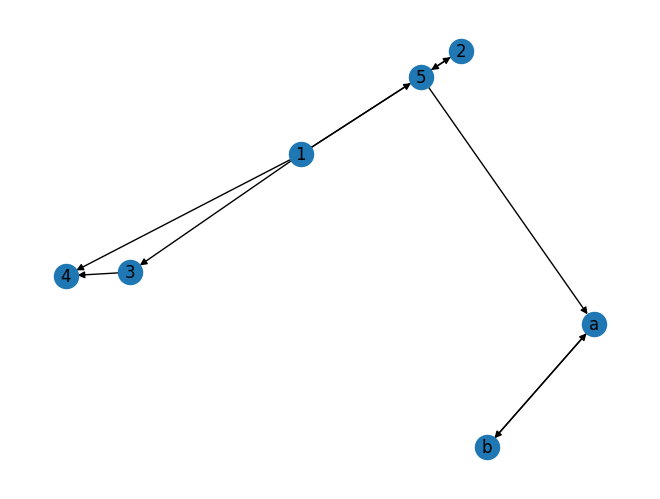

In [ ]:
toy_g.edges(data=True)

# Add:
# - two vertices, with name "a" and "b"
# - weighted links between them
# - a link from "5" to "a"

# Note that we don't need to explictly add the nodes first, networkx does it for us. But if we do, it's okay
# toy_g.add_nodes_from(["a","b"])
toy_g.add_edge("5","a", weight = 0.03)
toy_g.add_edges_from([("b","a", {'weight': 0.01}), ("a","b", {'weight' : 0.02})])

toy_g.edges(data=True)

nx.draw(toy_g, with_labels = True)

### Removing Edges

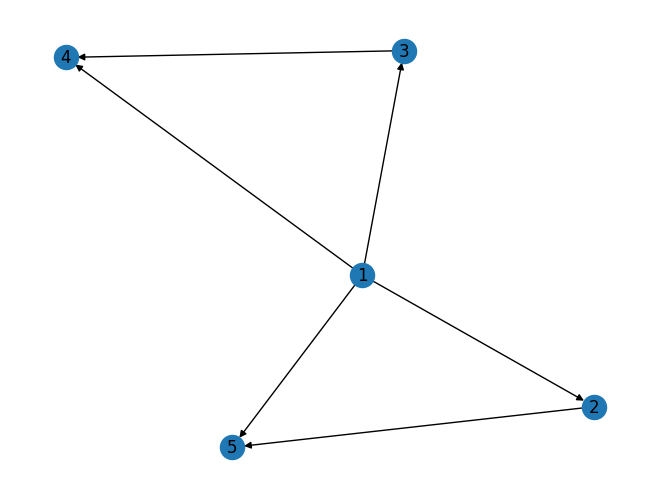

In [ ]:
toy_g.remove_edge("5","a")
toy_g.remove_edges_from([("b","a"), ("a","b")])

toy_g.remove_nodes_from(["a","b"])

nx.draw(toy_g, with_labels = True)

### Adding node attributes

In [ ]:
toy_g.add_nodes_from(toy_g.nodes(), nodetype = 'number') # adds attribute 'nodetype' with default value 'number'

toy_g.add_node('a', nodetype = 'letter') # for node 'a', we set the attribute value of 'nodetype' to 'letter'
toy_g.nodes['a']['capitalization'] = 'small' # we add another attribute 'capitalization' and set the value to 'small'


toy_g.nodes(data = True)

NodeDataView({'1': {'nodetype': 'number'}, '2': {'nodetype': 'number'}, '3': {'nodetype': 'number'}, '4': {'nodetype': 'number'}, '5': {'nodetype': 'number'}, 'a': {'nodetype': 'letter', 'capitalization': 'small'}})

### Adding edge attributes

In [ ]:
toy_g.add_edges_from(toy_g.edges(), edgeatt = 'default') # adds "edgeatt" set to "default"

toy_g.edges(data = True)

# two ways of changing the edge attribute value
toy_g['1']['2']['edgeatt'] = 'changed' # indexing from graph
toy_g.edges['3','4']['edgeatt'] = 'changed' # indexing from toy_g.edges


toy_g.edges(data = True)

OutEdgeDataView([('1', '2', {'weight': 0.1, 'edgeatt': 'default'}), ('1', '3', {'weight': 0.3, 'edgeatt': 'default'}), ('1', '4', {'weight': 0.01, 'edgeatt': 'default'}), ('1', '5', {'weight': 0.5, 'edgeatt': 'default'}), ('2', '5', {'weight': 1.0, 'edgeatt': 'default'}), ('3', '4', {'weight': 0.9, 'edgeatt': 'default'})])

OutEdgeDataView([('1', '2', {'weight': 0.1, 'edgeatt': 'changed'}), ('1', '3', {'weight': 0.3, 'edgeatt': 'default'}), ('1', '4', {'weight': 0.01, 'edgeatt': 'default'}), ('1', '5', {'weight': 0.5, 'edgeatt': 'default'}), ('2', '5', {'weight': 1.0, 'edgeatt': 'default'}), ('3', '4', {'weight': 0.9, 'edgeatt': 'changed'})])